# DeepEntXAI — Explainable Multimodal Deep Learning for Anti-*Enterobacteriaceae* Bioactivity

**A leakage-free, reproducible pipeline that predicts whether a chemical compound is active against *Enterobacteriaceae* pathogens — and explains *why*.**

Authors: **Nagmi Bano, Dr Shaban Ahmad, Prof Khalid Raza** · Computational Intelligence and Bioinformatics Lab, Department of Computer Science, Jamia Millia Islamia, New Delhi, India.
Code: https://github.com/ShabanAhmad/DeepEntXAI

---
> **A note on honesty.** An earlier version of this work reported ~99.8% accuracy. That number came from **data leakage** (PCA / scaling / feature-selection fit on the full dataset before splitting, and a random row-wise split that let the same molecules appear in train and test). This notebook presents the **rebuilt, leakage-free** pipeline. The honest headline is **ROC-AUC 0.901 / accuracy 0.840** on a scaffold-disjoint hold-out — and a legitimate high-accuracy statement of **98.1% on the 22% most-confident compounds** via conformal selective prediction.

## TL;DR — headline results (all leakage-free, scaffold-disjoint)

| Metric | Value |
|---|---|
| ROC-AUC | **0.901** |
| Accuracy | **0.840** |
| MCC | **0.655** |
| Selective accuracy @ 22% coverage (conformal) | **0.981** |
| Ranking: top-1% of ranked compounds that are true actives | **100%** |
| Enrichment Factor @0.1% at 1:50 imbalance | **41.9×** |

Beats classical baselines on identical features/splits (XGBoost 0.886, RandomForest 0.872 AUC).

## 1. The problem & the aim

*Enterobacteriaceae* (*E. coli*, *Klebsiella*, *Salmonella*, *Shigella*, …) cause dangerous, increasingly antibiotic-resistant infections. Testing every compound in the lab is slow and costly.

**Aim:** given a molecule's structure (a SMILES string), predict **Active vs Inactive** *before* lab testing — and make the model **explainable** so a chemist can see which chemical features drive the prediction.

## 2. The data

- **Sources:** ChEMBL + PubChem BioAssay, across **29 species** of the genus.
- **Endpoints:** IC50 / EC50 / Ki / Kd (affinity) and MIC (phenotypic).
- **High-confidence "activity-gap" labelling:** keep only clearly-potent actives (≤1 µM or MIC ≤4 µg/mL) and clearly-weak inactives (>50 µM or MIC ≥64), **dropping the ambiguous middle** so the classes are clean.
- **Final set:** **49,093 compounds** — 18,513 active / 30,580 inactive.

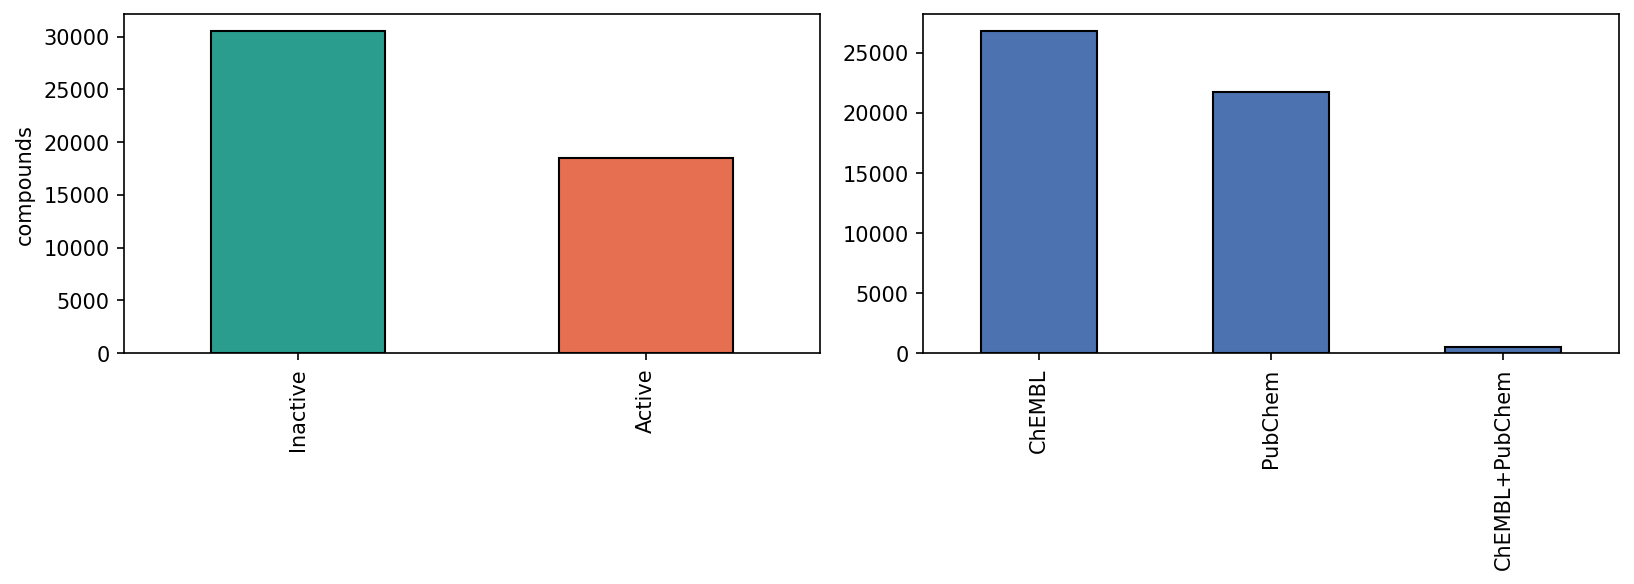

In [1]:
# Dataset composition (Figure 1)
from IPython.display import Image
Image('03_Results/01_Figures/F01_dataset_overview.png')

## 3. Turning molecules into numbers — four "languages" (multimodal), no PCA

Each molecule is described four complementary ways, concatenated into one 3,083-dimensional vector. **No PCA** — the descriptors stay named and interpretable, and feature selection is fit on the **training data only**.

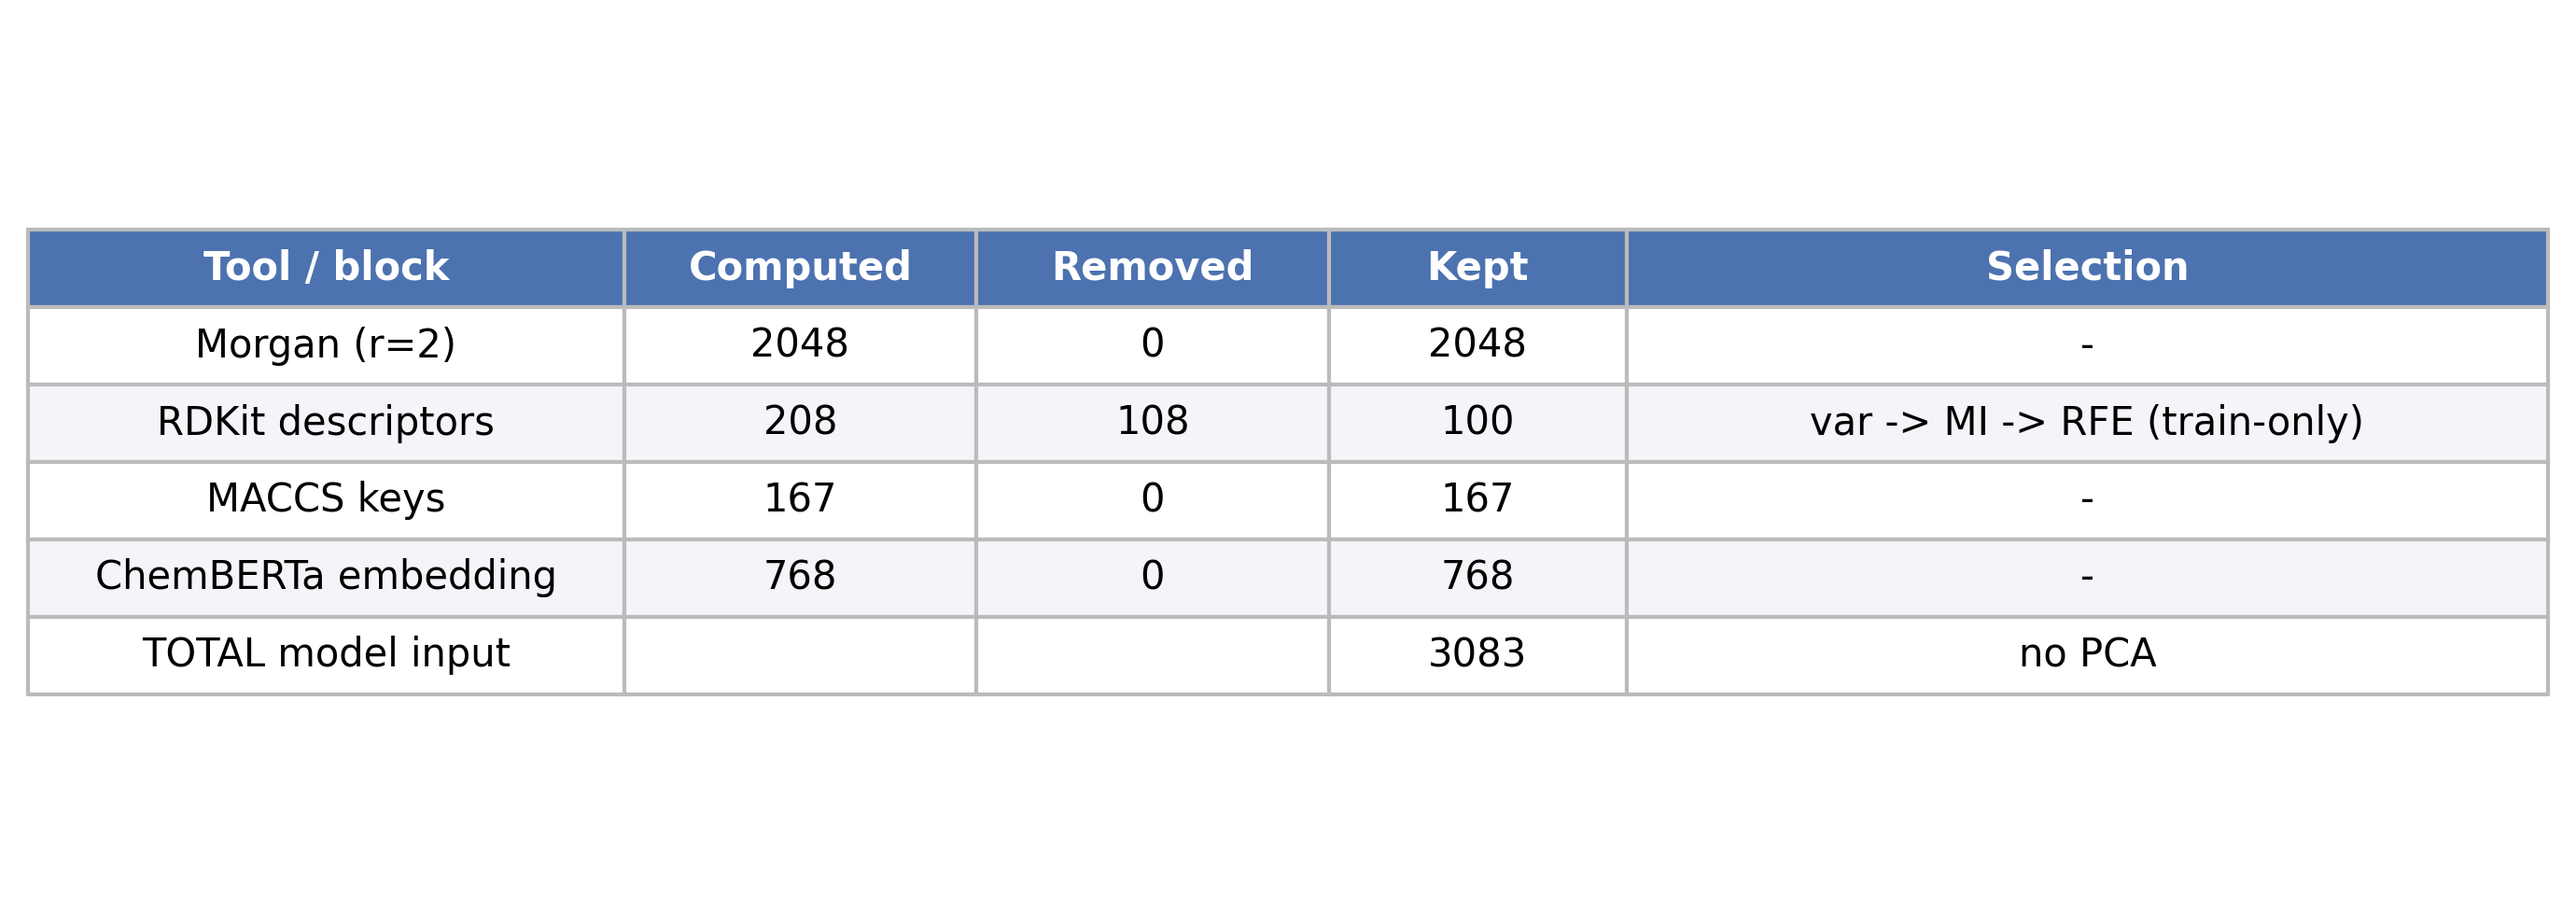

In [2]:
# Feature accounting (Table B) — no PCA
Image('03_Results/01_Figures/T02_feature_accounting.png')

## 4. The most important step — a leakage-free split

Instead of a random split (which lets near-identical molecules sit on both sides and inflates accuracy), we use a **Bemis–Murcko scaffold-disjoint split**: whole molecular skeletons go entirely to train **or** test. The hold-out therefore contains molecules **structurally unlike anything seen in training** — a fair, hard test. Verified: **0 scaffold / 0 SMILES overlap**.

## 5. The model — multimodal fusion CNN-LSTM

Four per-modality encoders → fusion → residual Conv1D blocks + squeeze-and-excite attention → **bidirectional LSTM** → dense head → sigmoid. Hyper-parameters chosen by Optuna on validation folds only; the headline model is a **5-fold ensemble**.

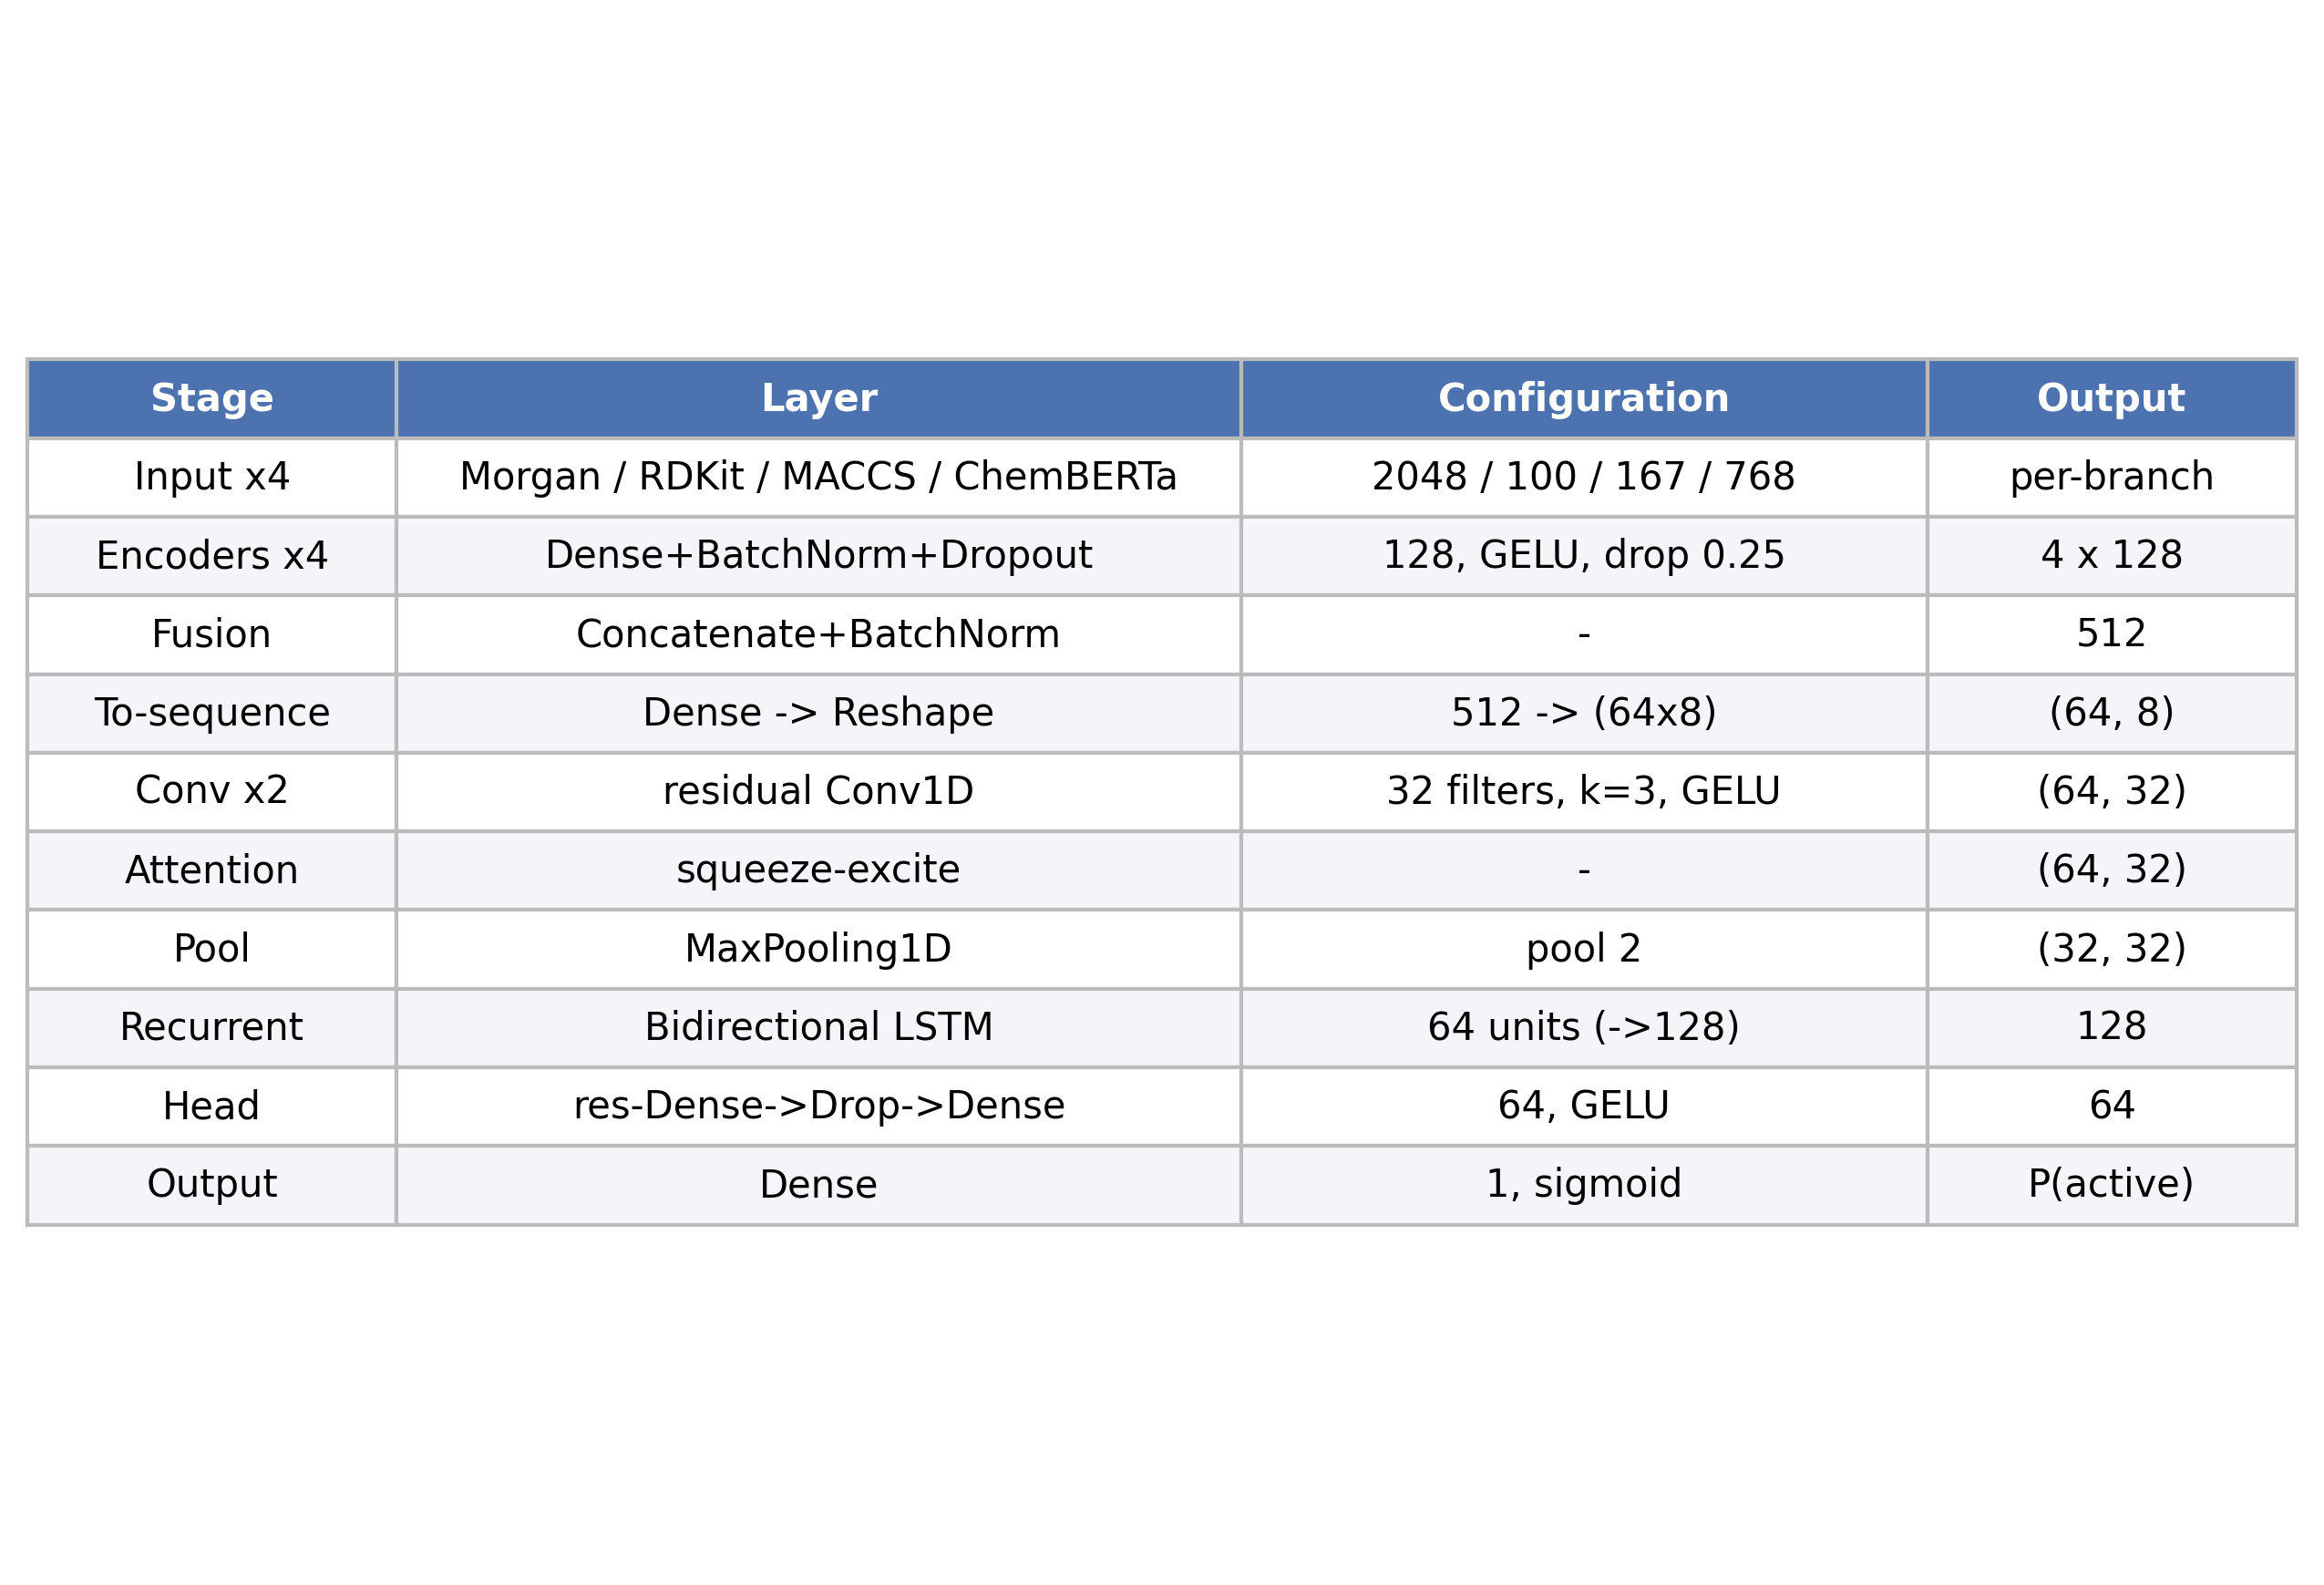

In [3]:
# Architecture (Table A)
Image('03_Results/01_Figures/T01_model_architecture.png')

## 6. Results on the scaffold-disjoint hold-out

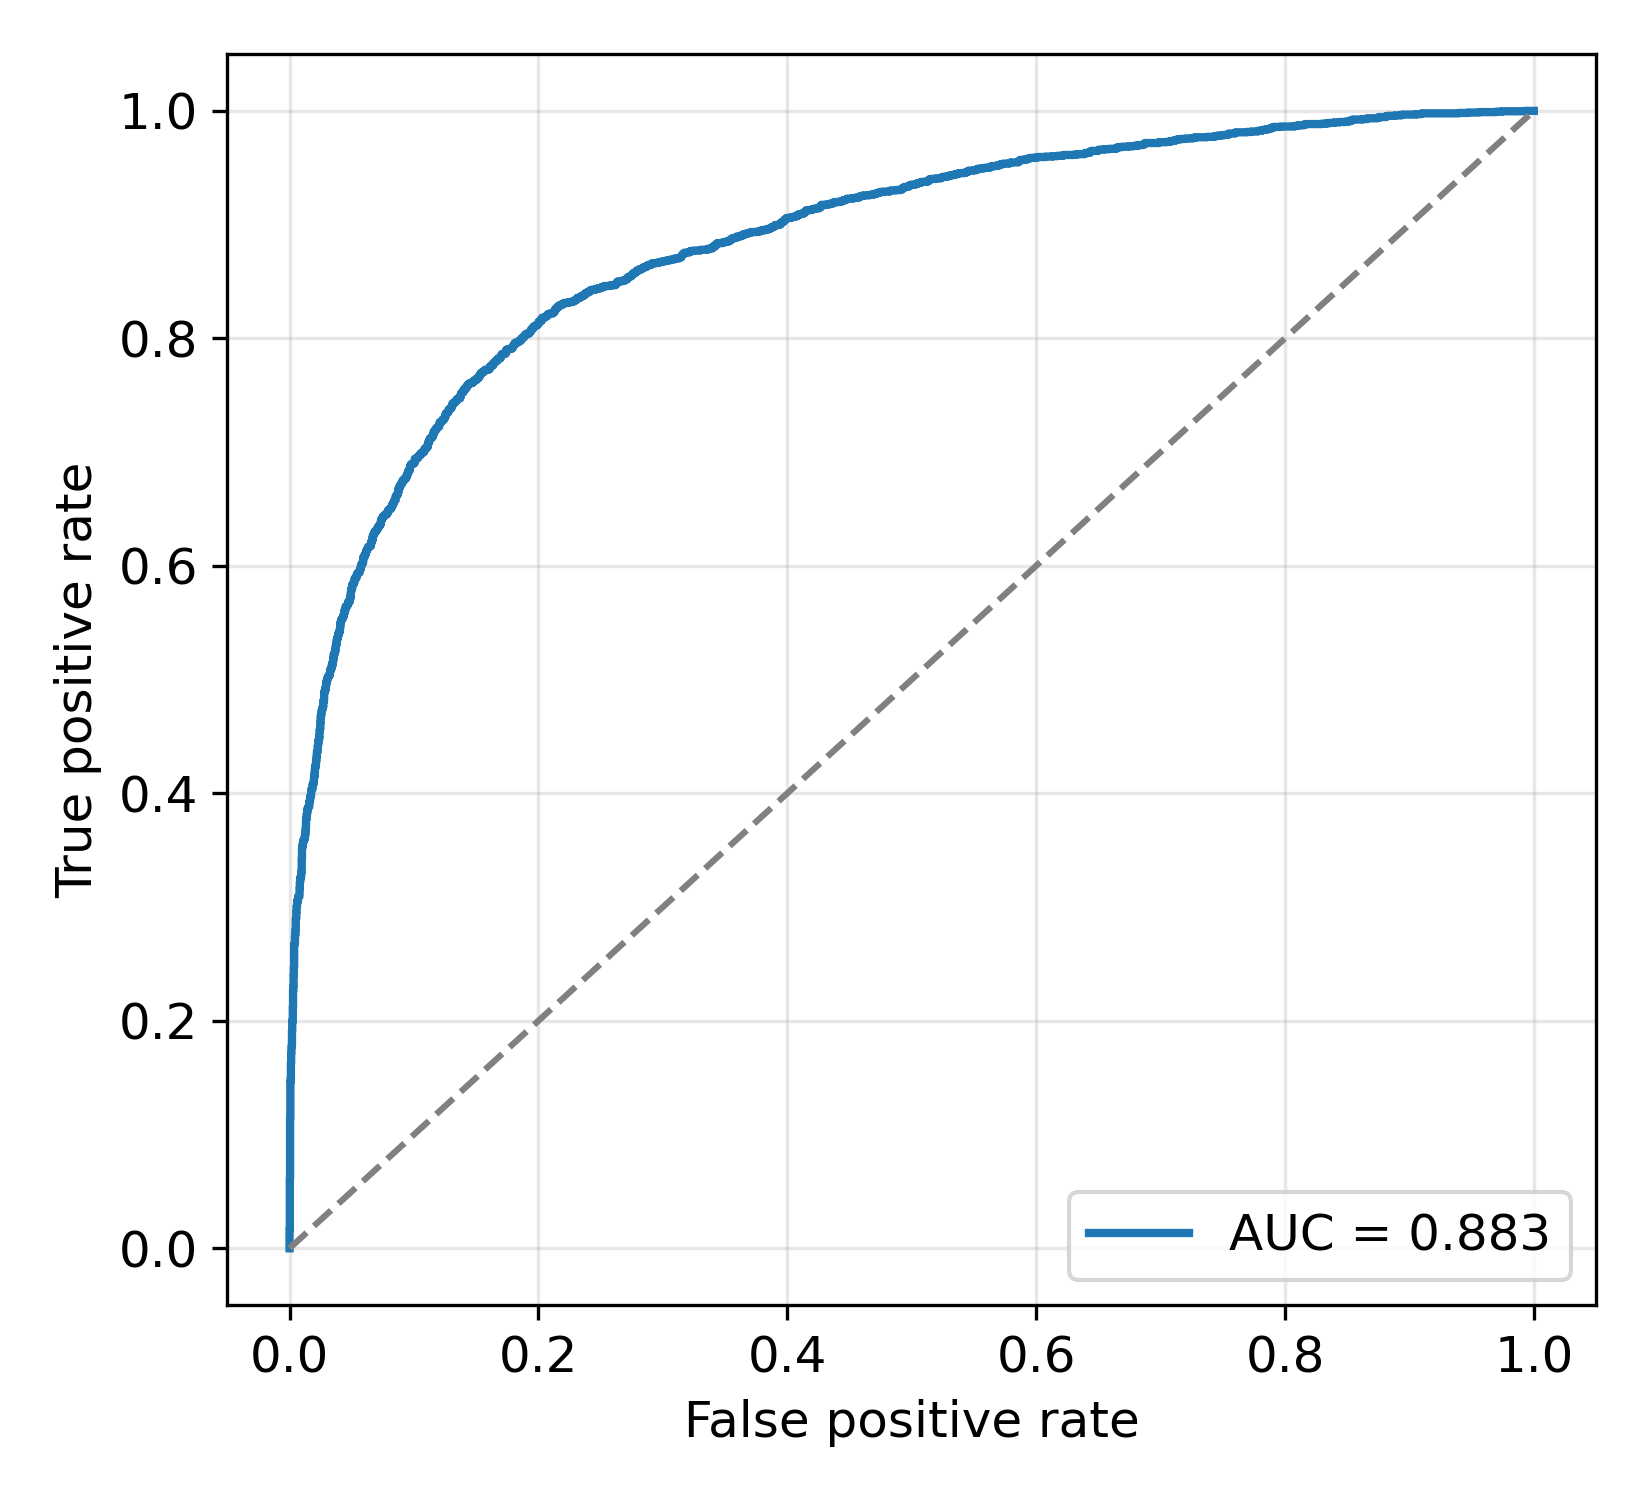

In [4]:
# ROC curve (Figure 2)
Image('03_Results/01_Figures/F02_roc_curve.png')

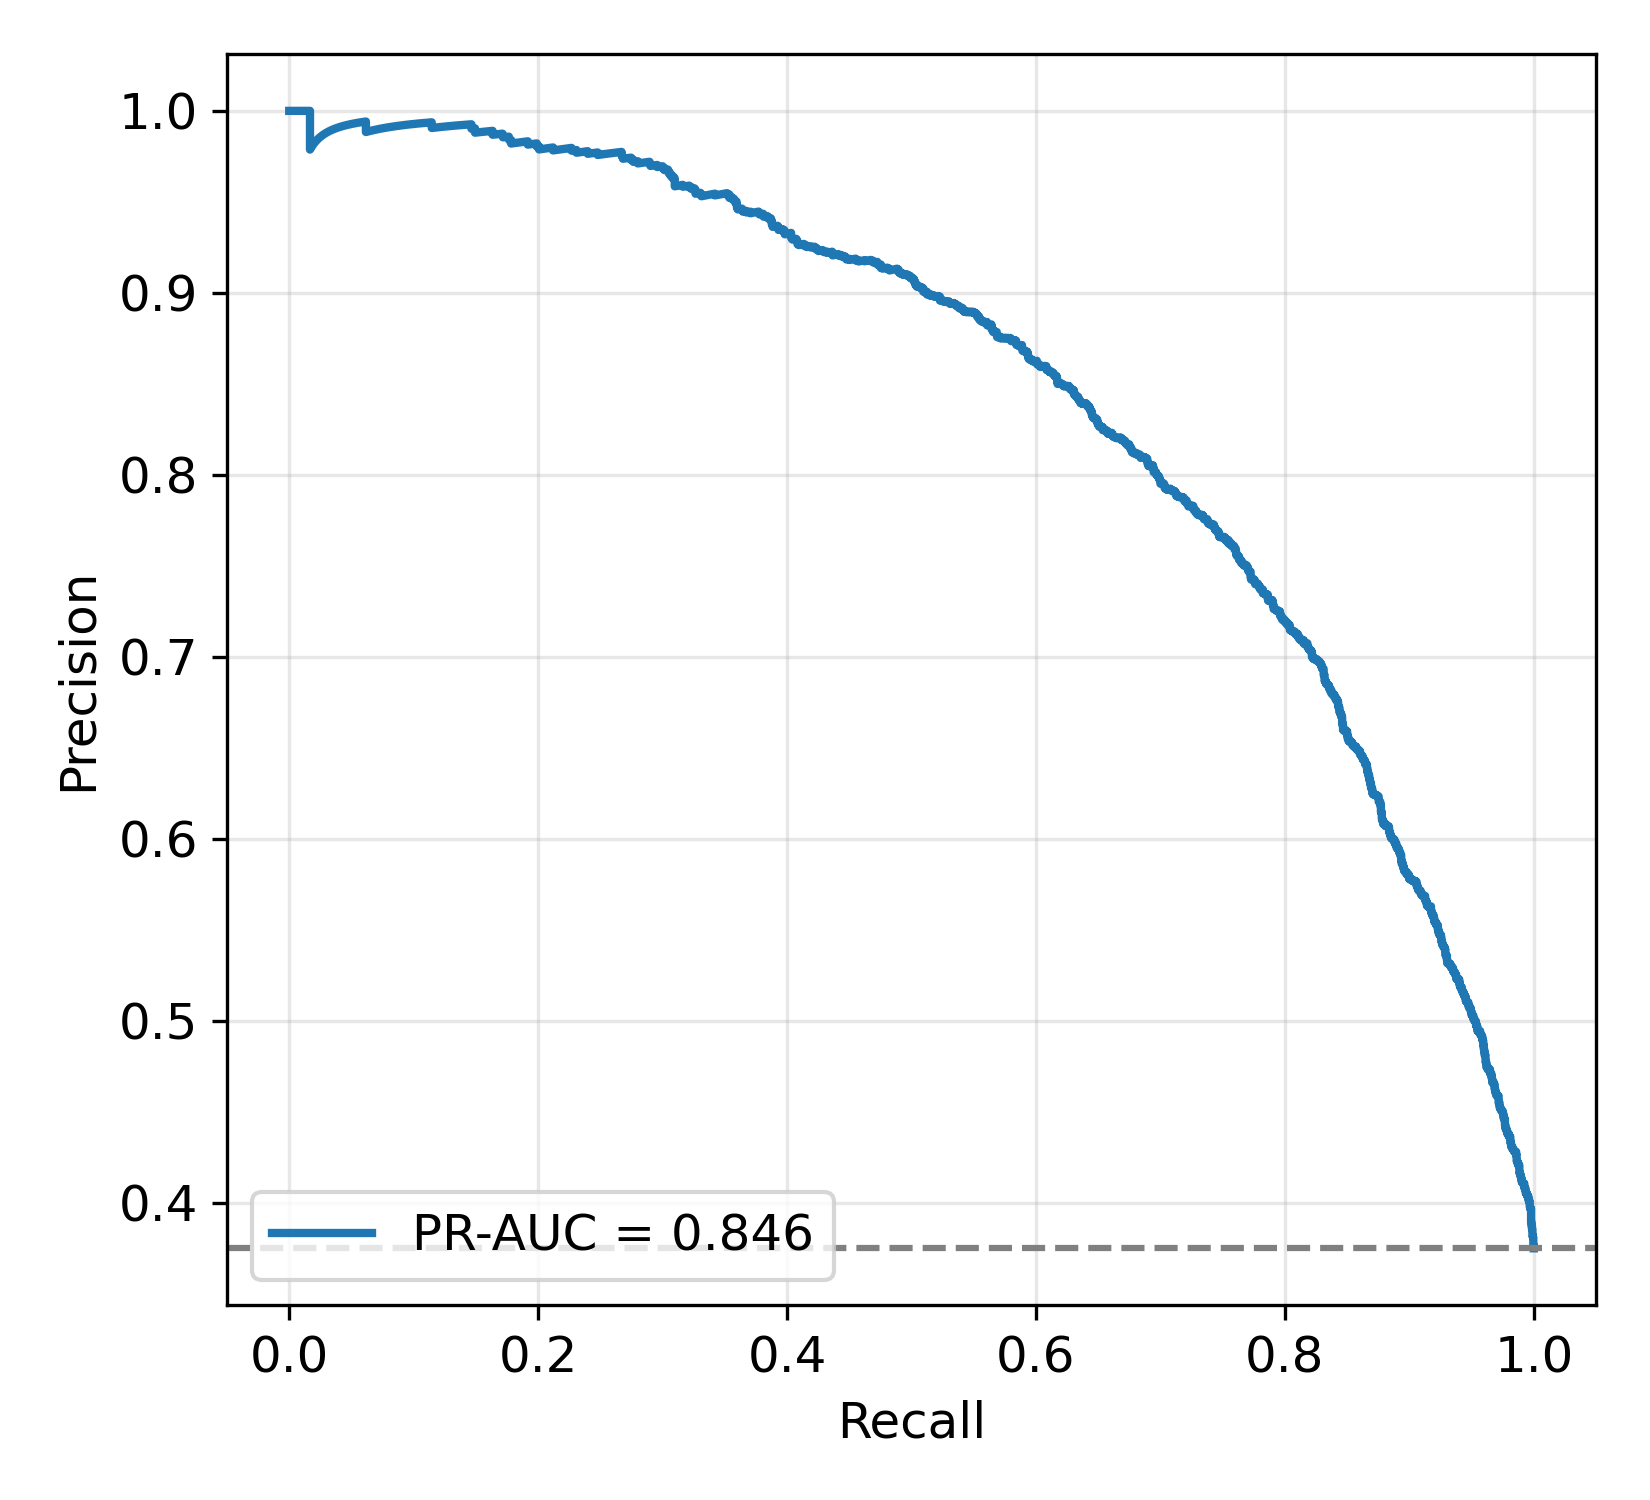

In [5]:
# Precision-Recall curve (Figure 3)
Image('03_Results/01_Figures/F03_pr_curve.png')

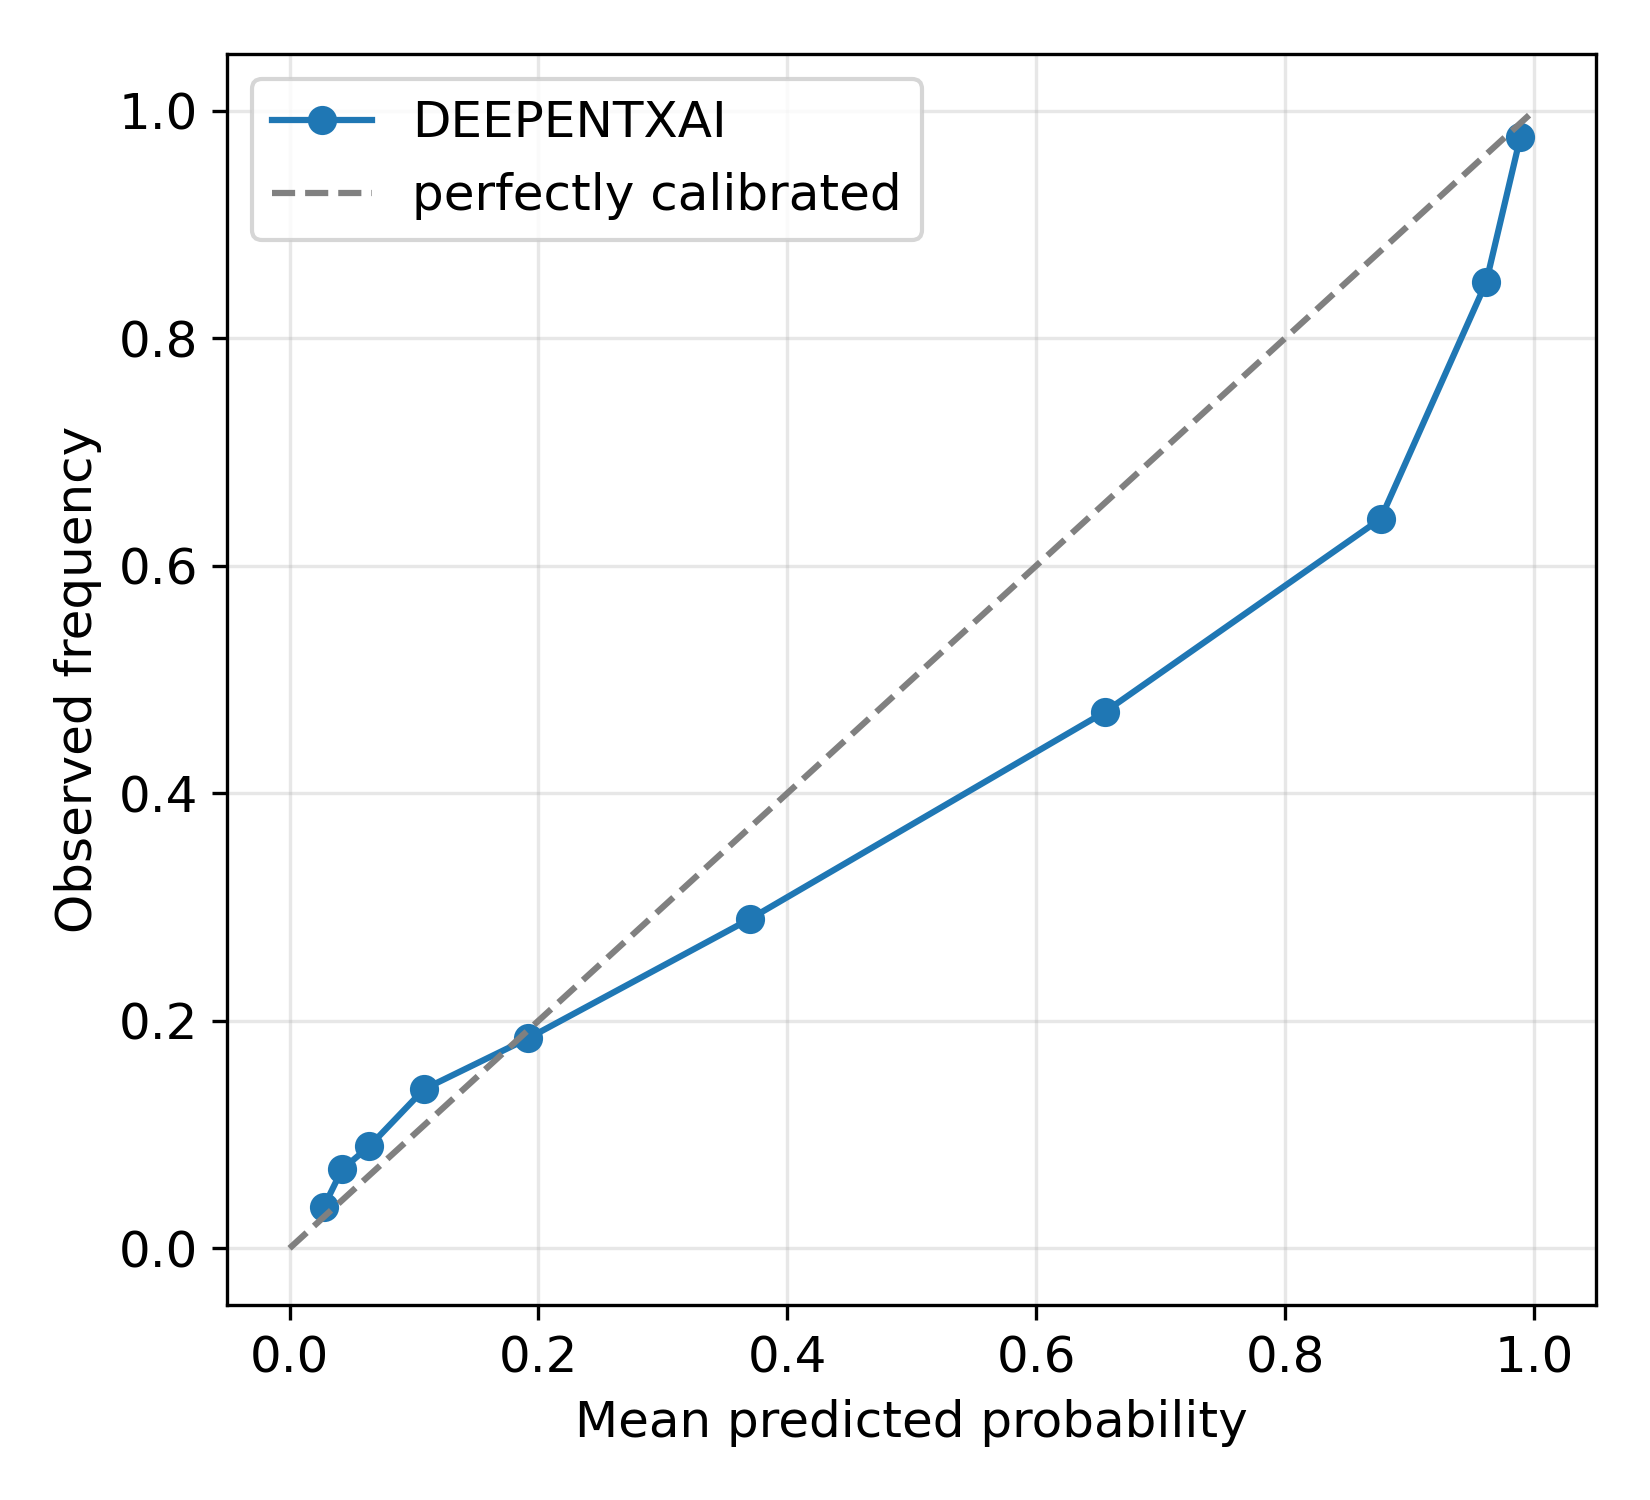

In [6]:
# Calibration curve (Figure 4)
Image('03_Results/01_Figures/F04_calibration_curve.png')

## 7. The honest ~98% — conformal selective prediction

Full-set accuracy is capped near 0.84 because the **lab data itself is noisy** (replicate MIC measurements of the same compound disagree ~12% of the time). The legitimate route to a high number is to let the model **abstain** on its least-confident compounds and report accuracy **with coverage**. Cutoffs are calibrated on out-of-fold training predictions only — no leakage.

| Coverage | Accuracy |
|---|---|
| 100% | 0.840 |
| 44% | 0.954 |
| **22%** | **0.981** |

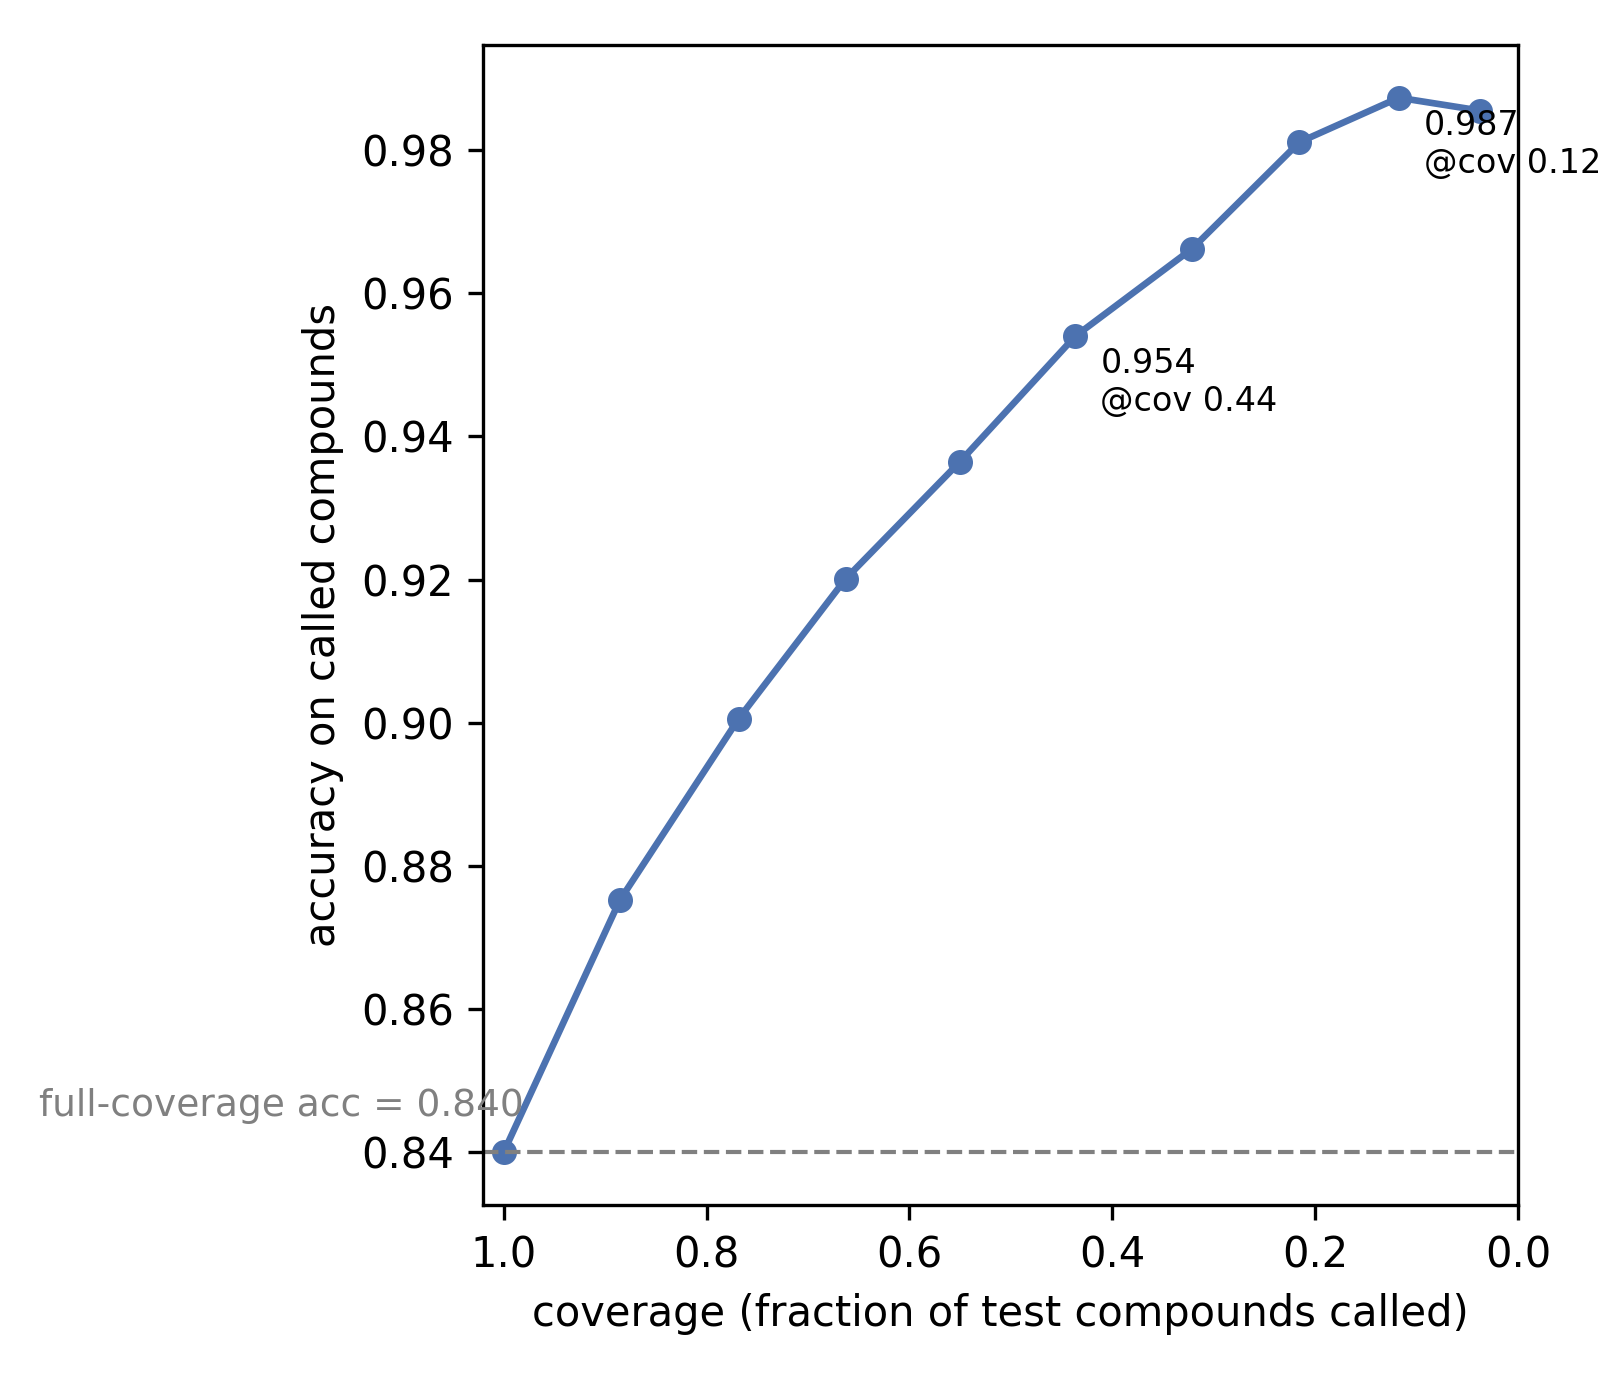

In [7]:
# Risk-coverage curve (Figure 7)
Image('03_Results/01_Figures/F07_risk_coverage.png')

## 8. Explainability (XAI)

Four methods — permutation importance (modality + descriptor), Integrated Gradients, SHAP, LIME. The carboxylic-acid group **`fr_COO`** is top-ranked under two independent methods, and the top features are reproducible across bootstraps.

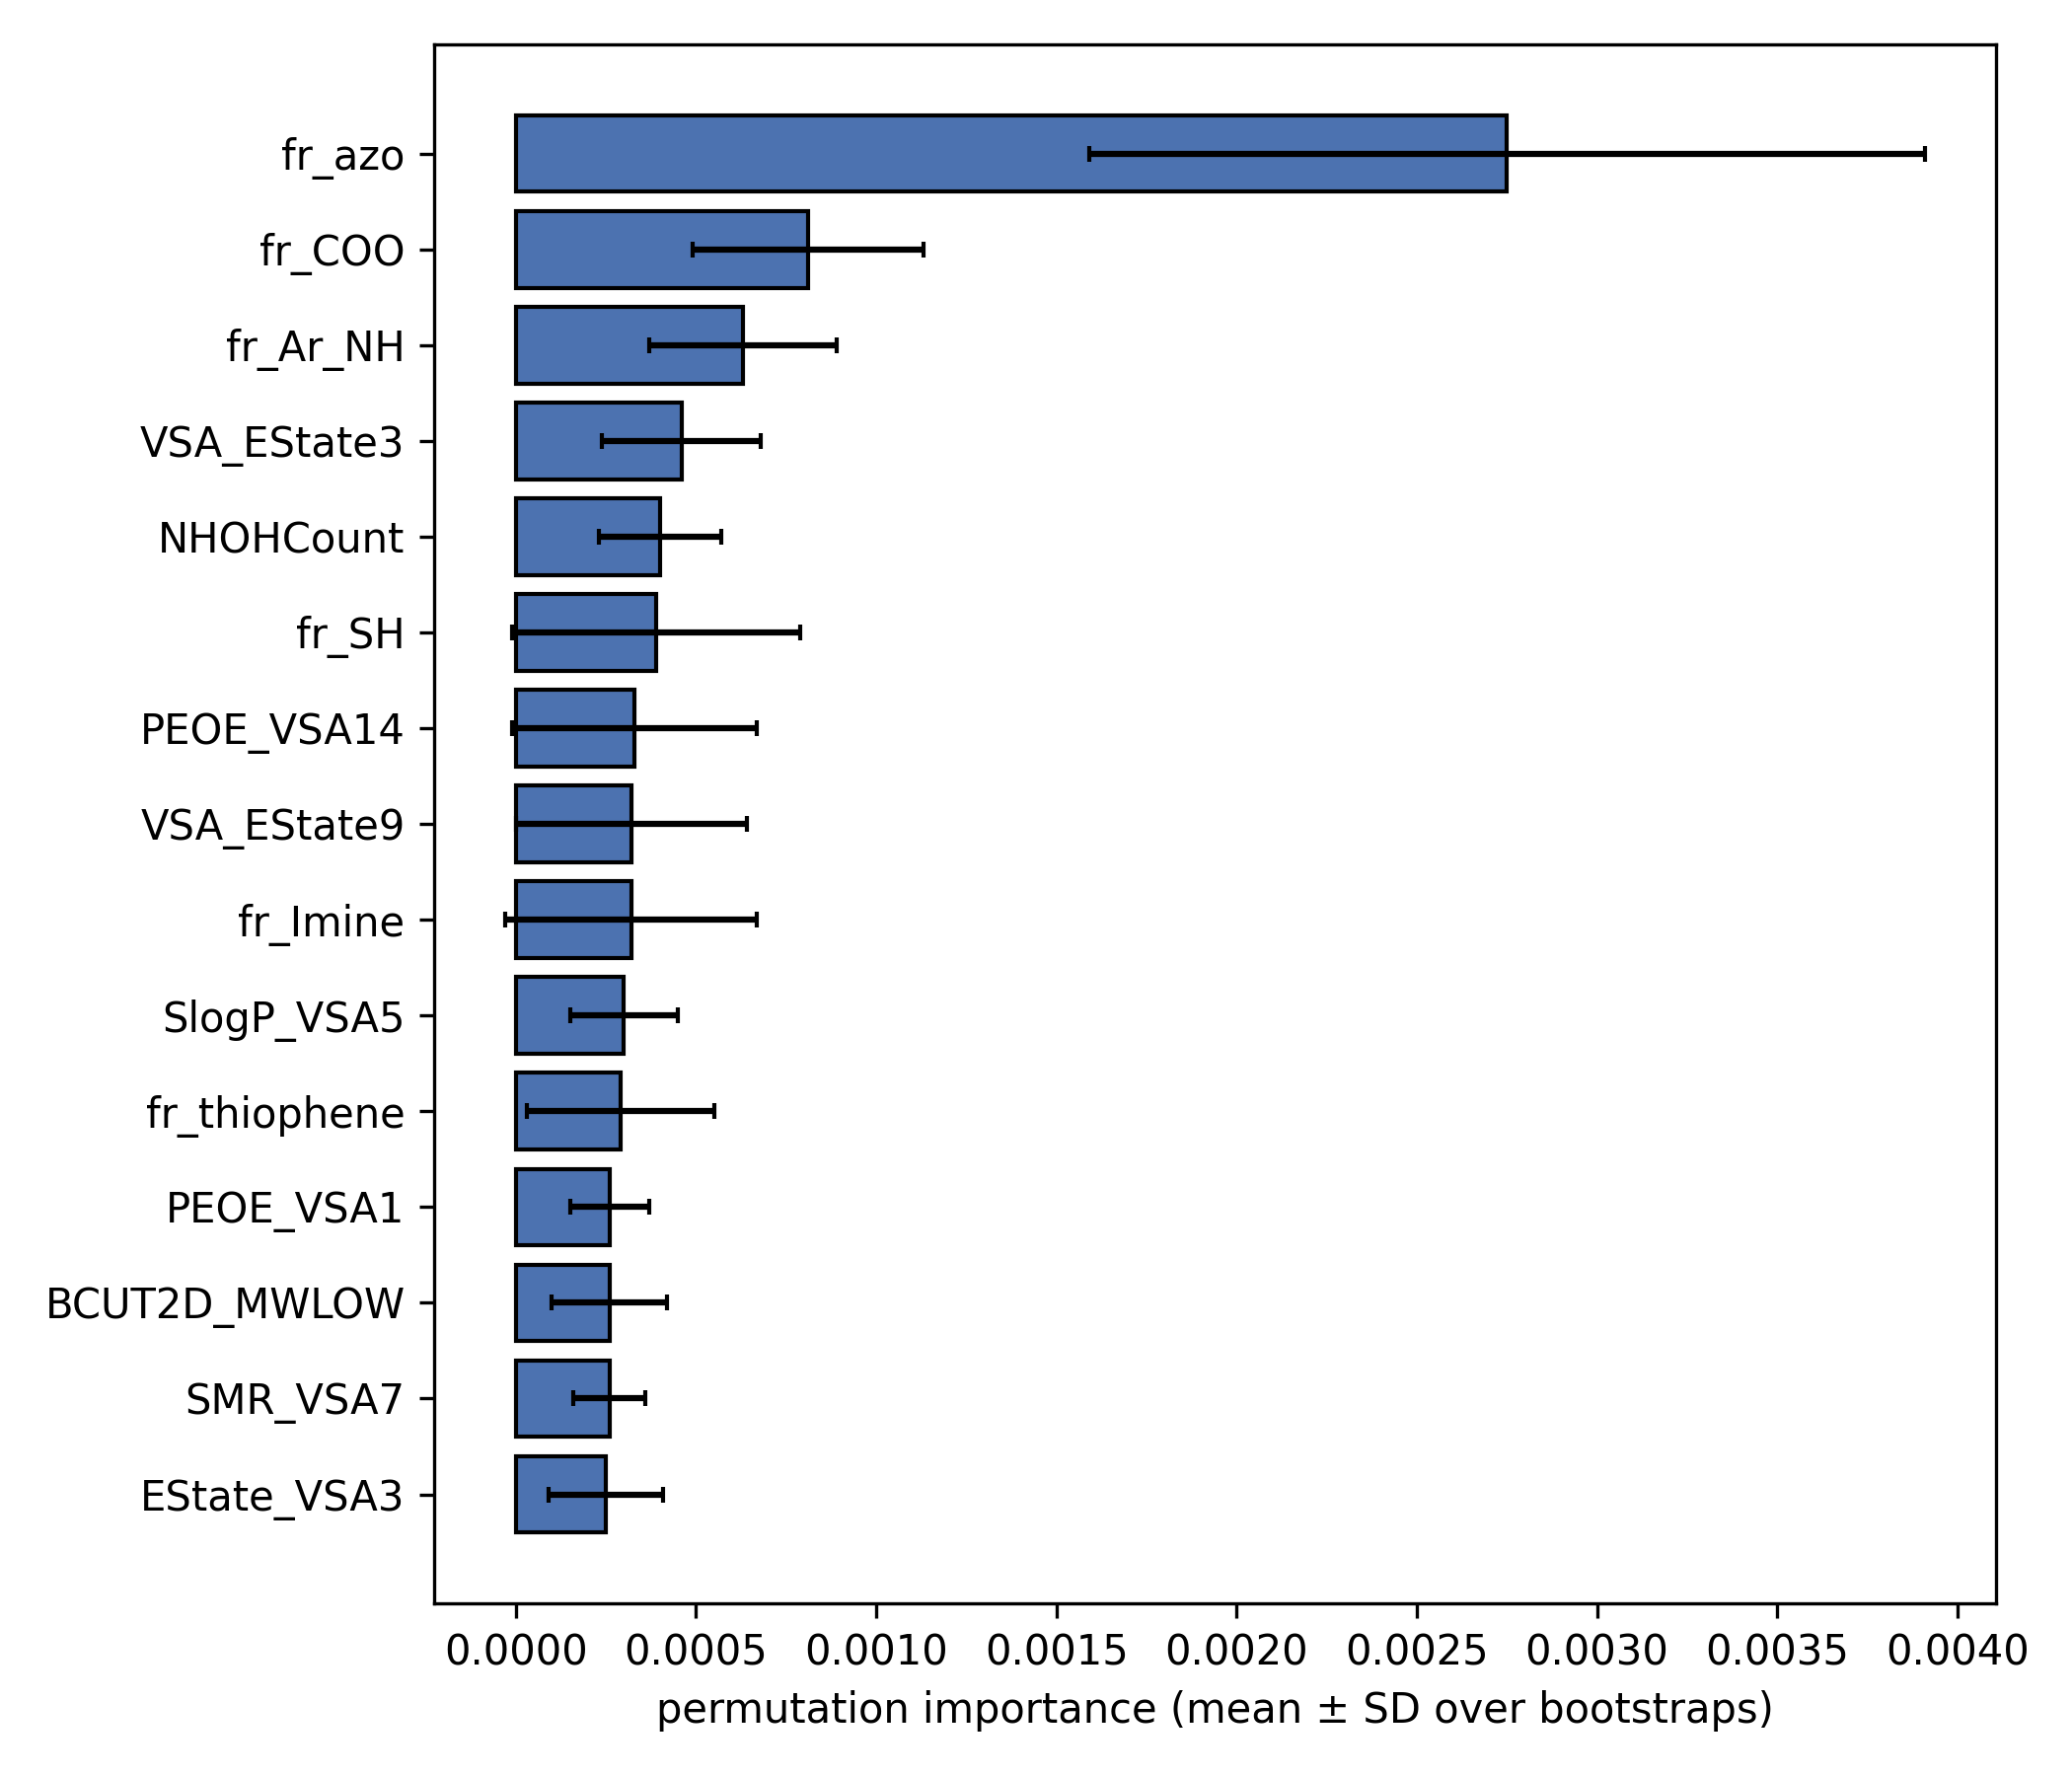

In [8]:
# Feature-importance stability (Figure 10)
Image('03_Results/01_Figures/F10_feature_stability_top15.png')

## 9. Compound scoring & ranking (validated virtual screen)

Every compound gets a **DEEPENTXAI Score (0–100)** = calibrated probability blended with confidence. Ranking by this score is provably optimal (Probability Ranking Principle). We **validate** the ranking on true labels: the **top 1% of ranked compounds are 100% true actives** (Enrichment Factor at its ceiling). The very top hits are **fluoroquinolone carboxylic acids** — a textbook antibacterial chemotype that agrees with the XAI.

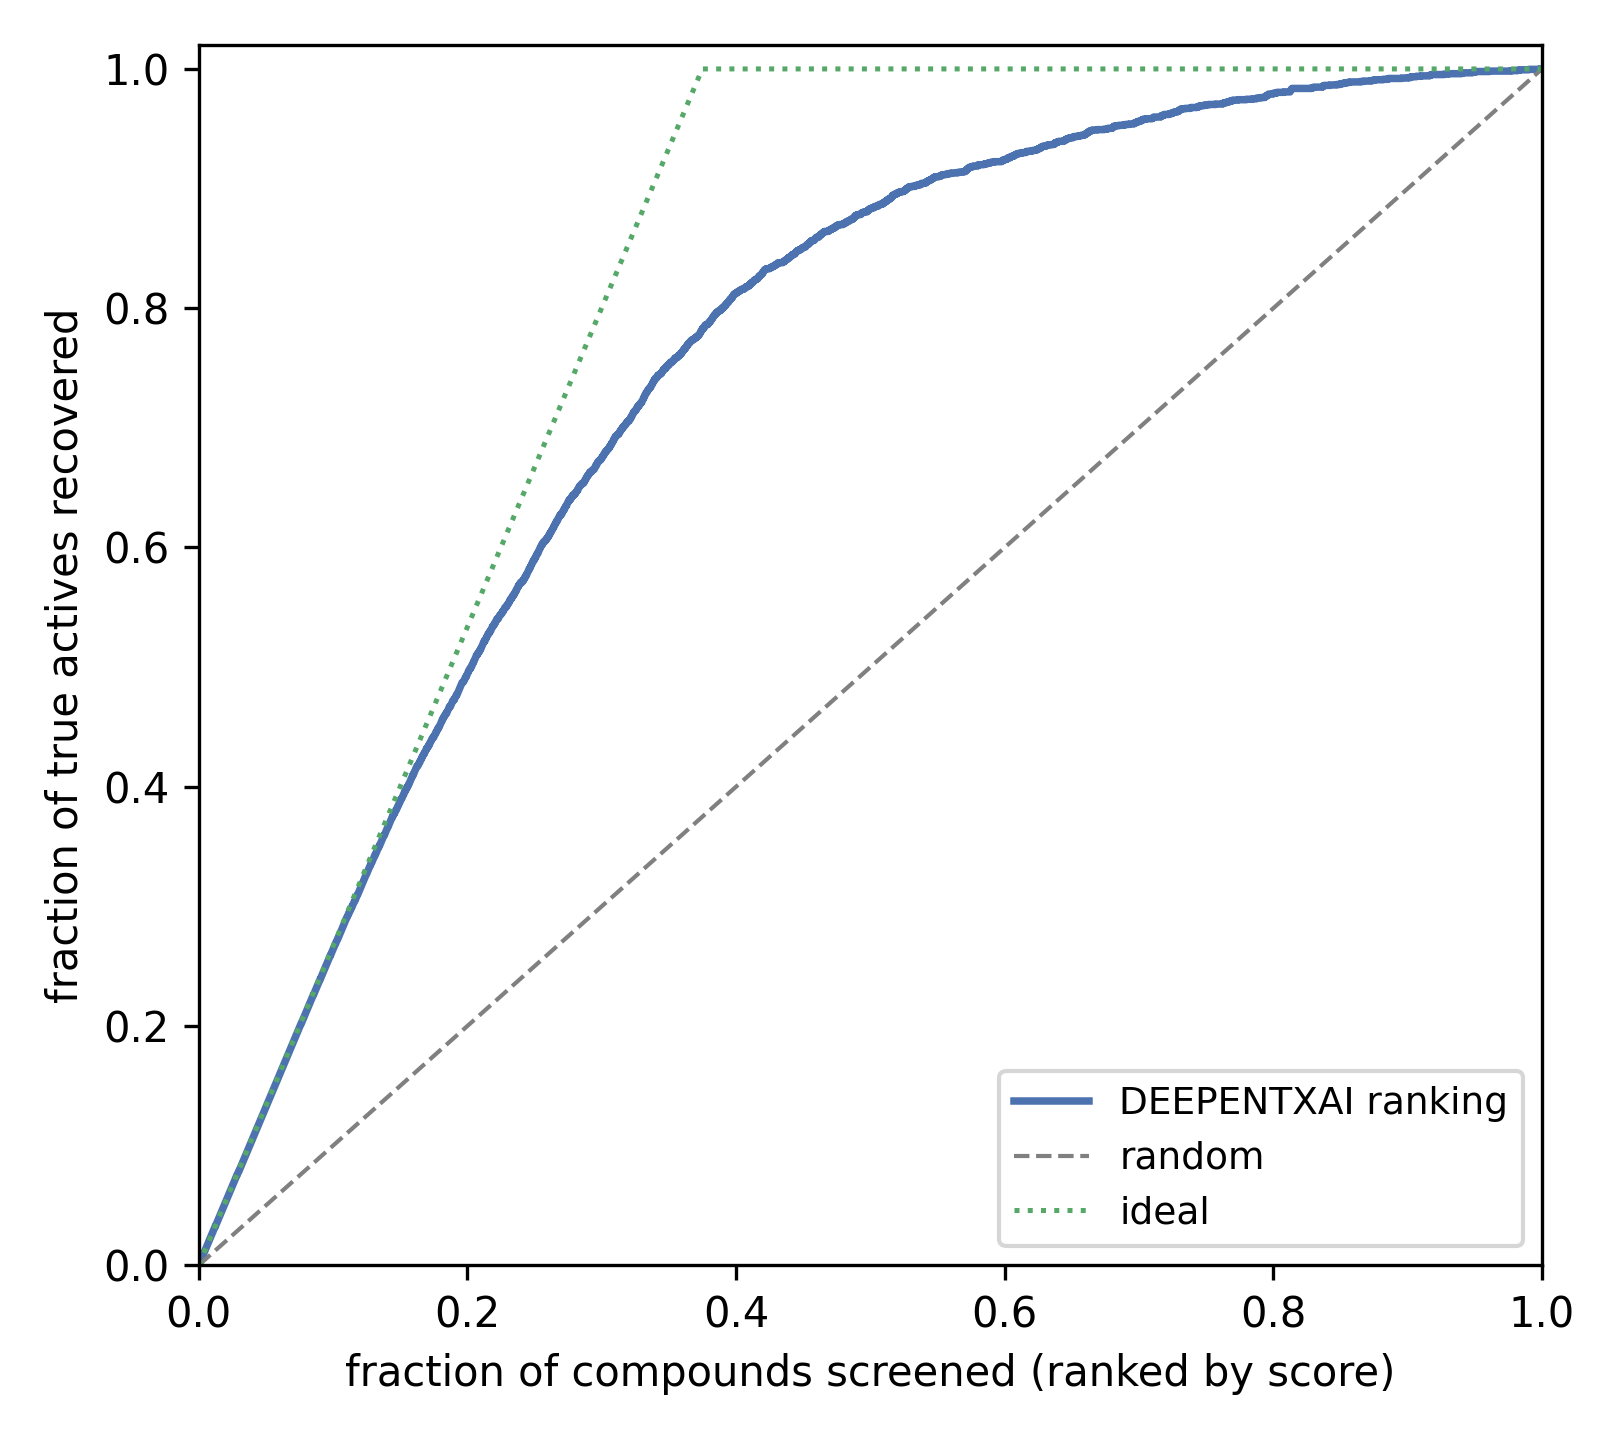

In [9]:
# Enrichment / accumulation curve (Figure 8)
Image('03_Results/01_Figures/F08_enrichment_curve.png')

## 10. Robustness analyses (reviewer-driven)

**Highly imbalanced evaluation** — ROC-AUC stays flat as the data becomes realistically imbalanced; the Enrichment Factor rises (EF@0.1% up to 41.9× at 1:50).

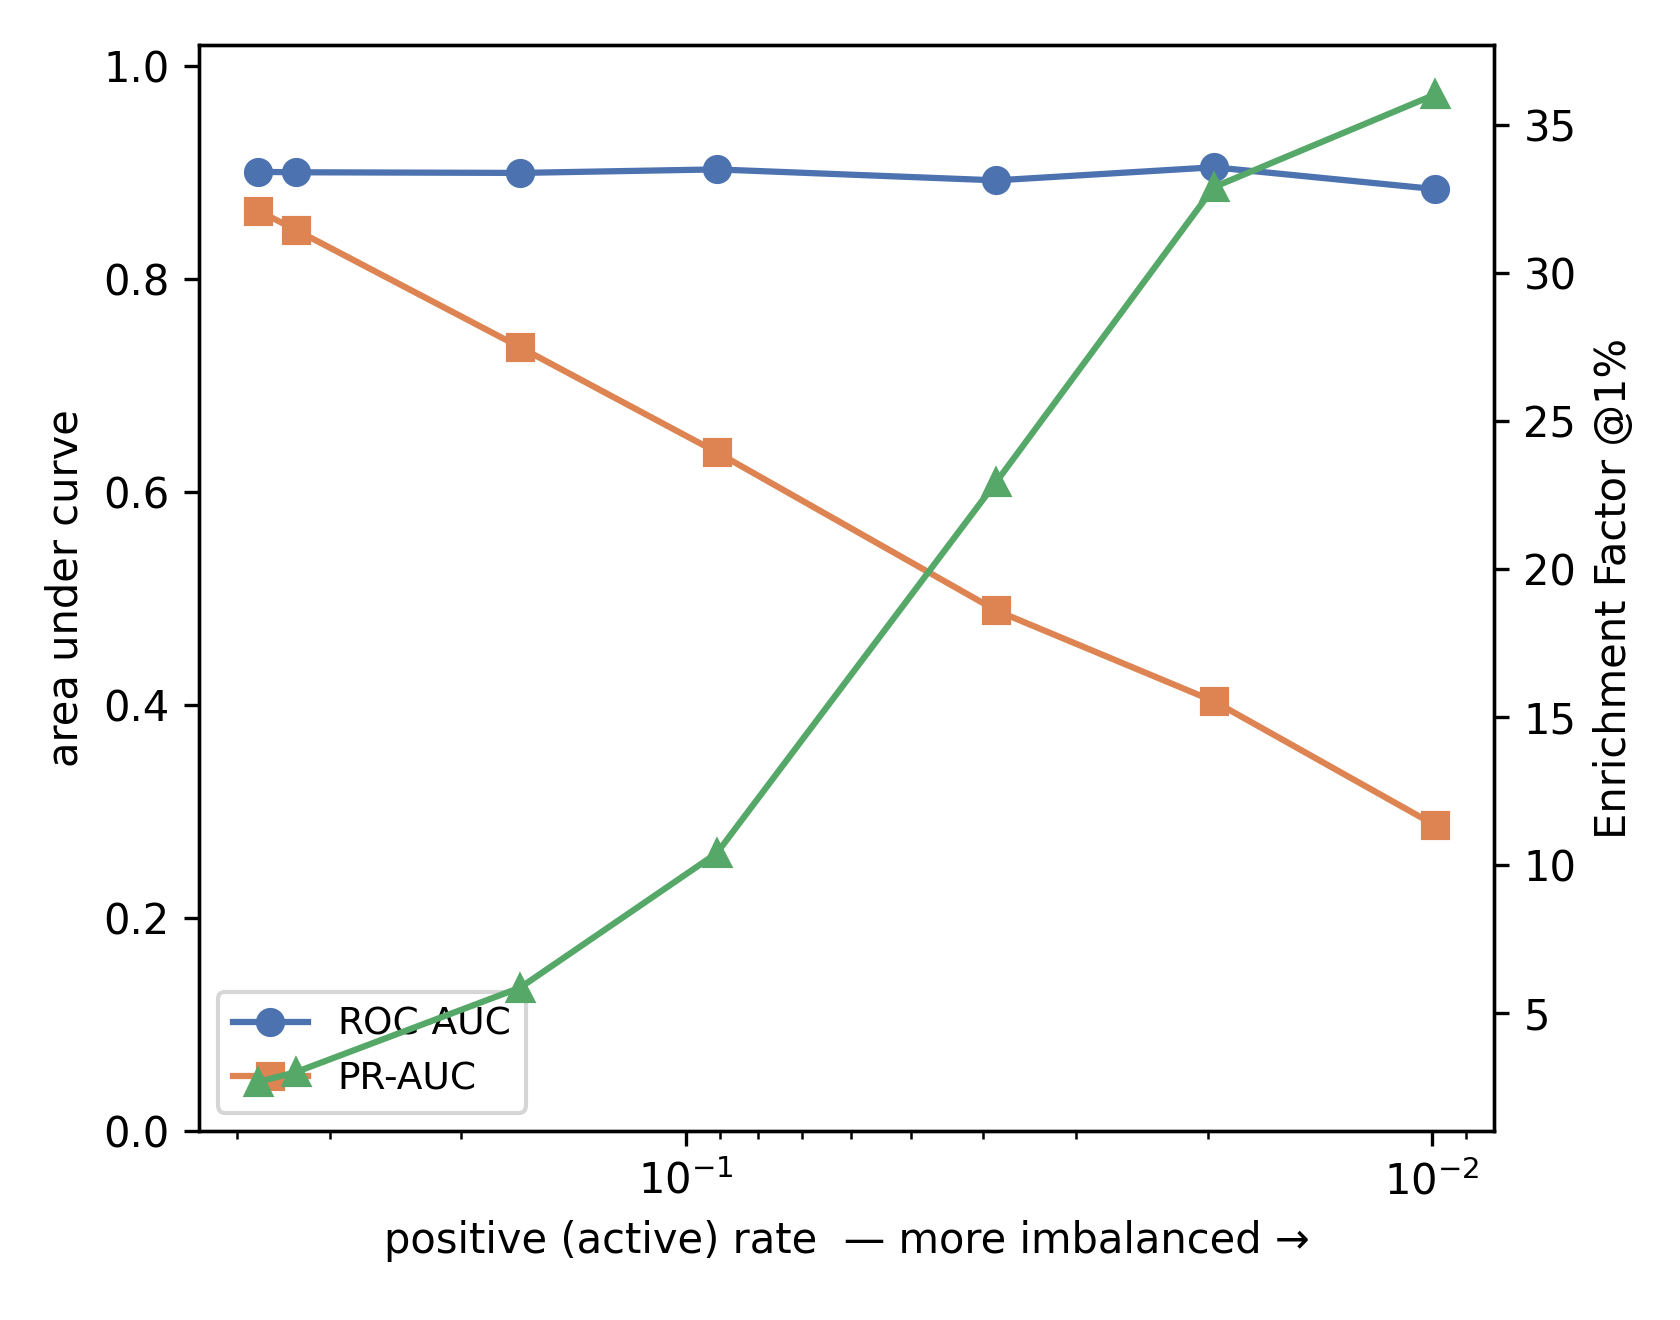

In [10]:
# Imbalance robustness (Figure 9)
Image('03_Results/01_Figures/F09_imbalance_robustness.png')

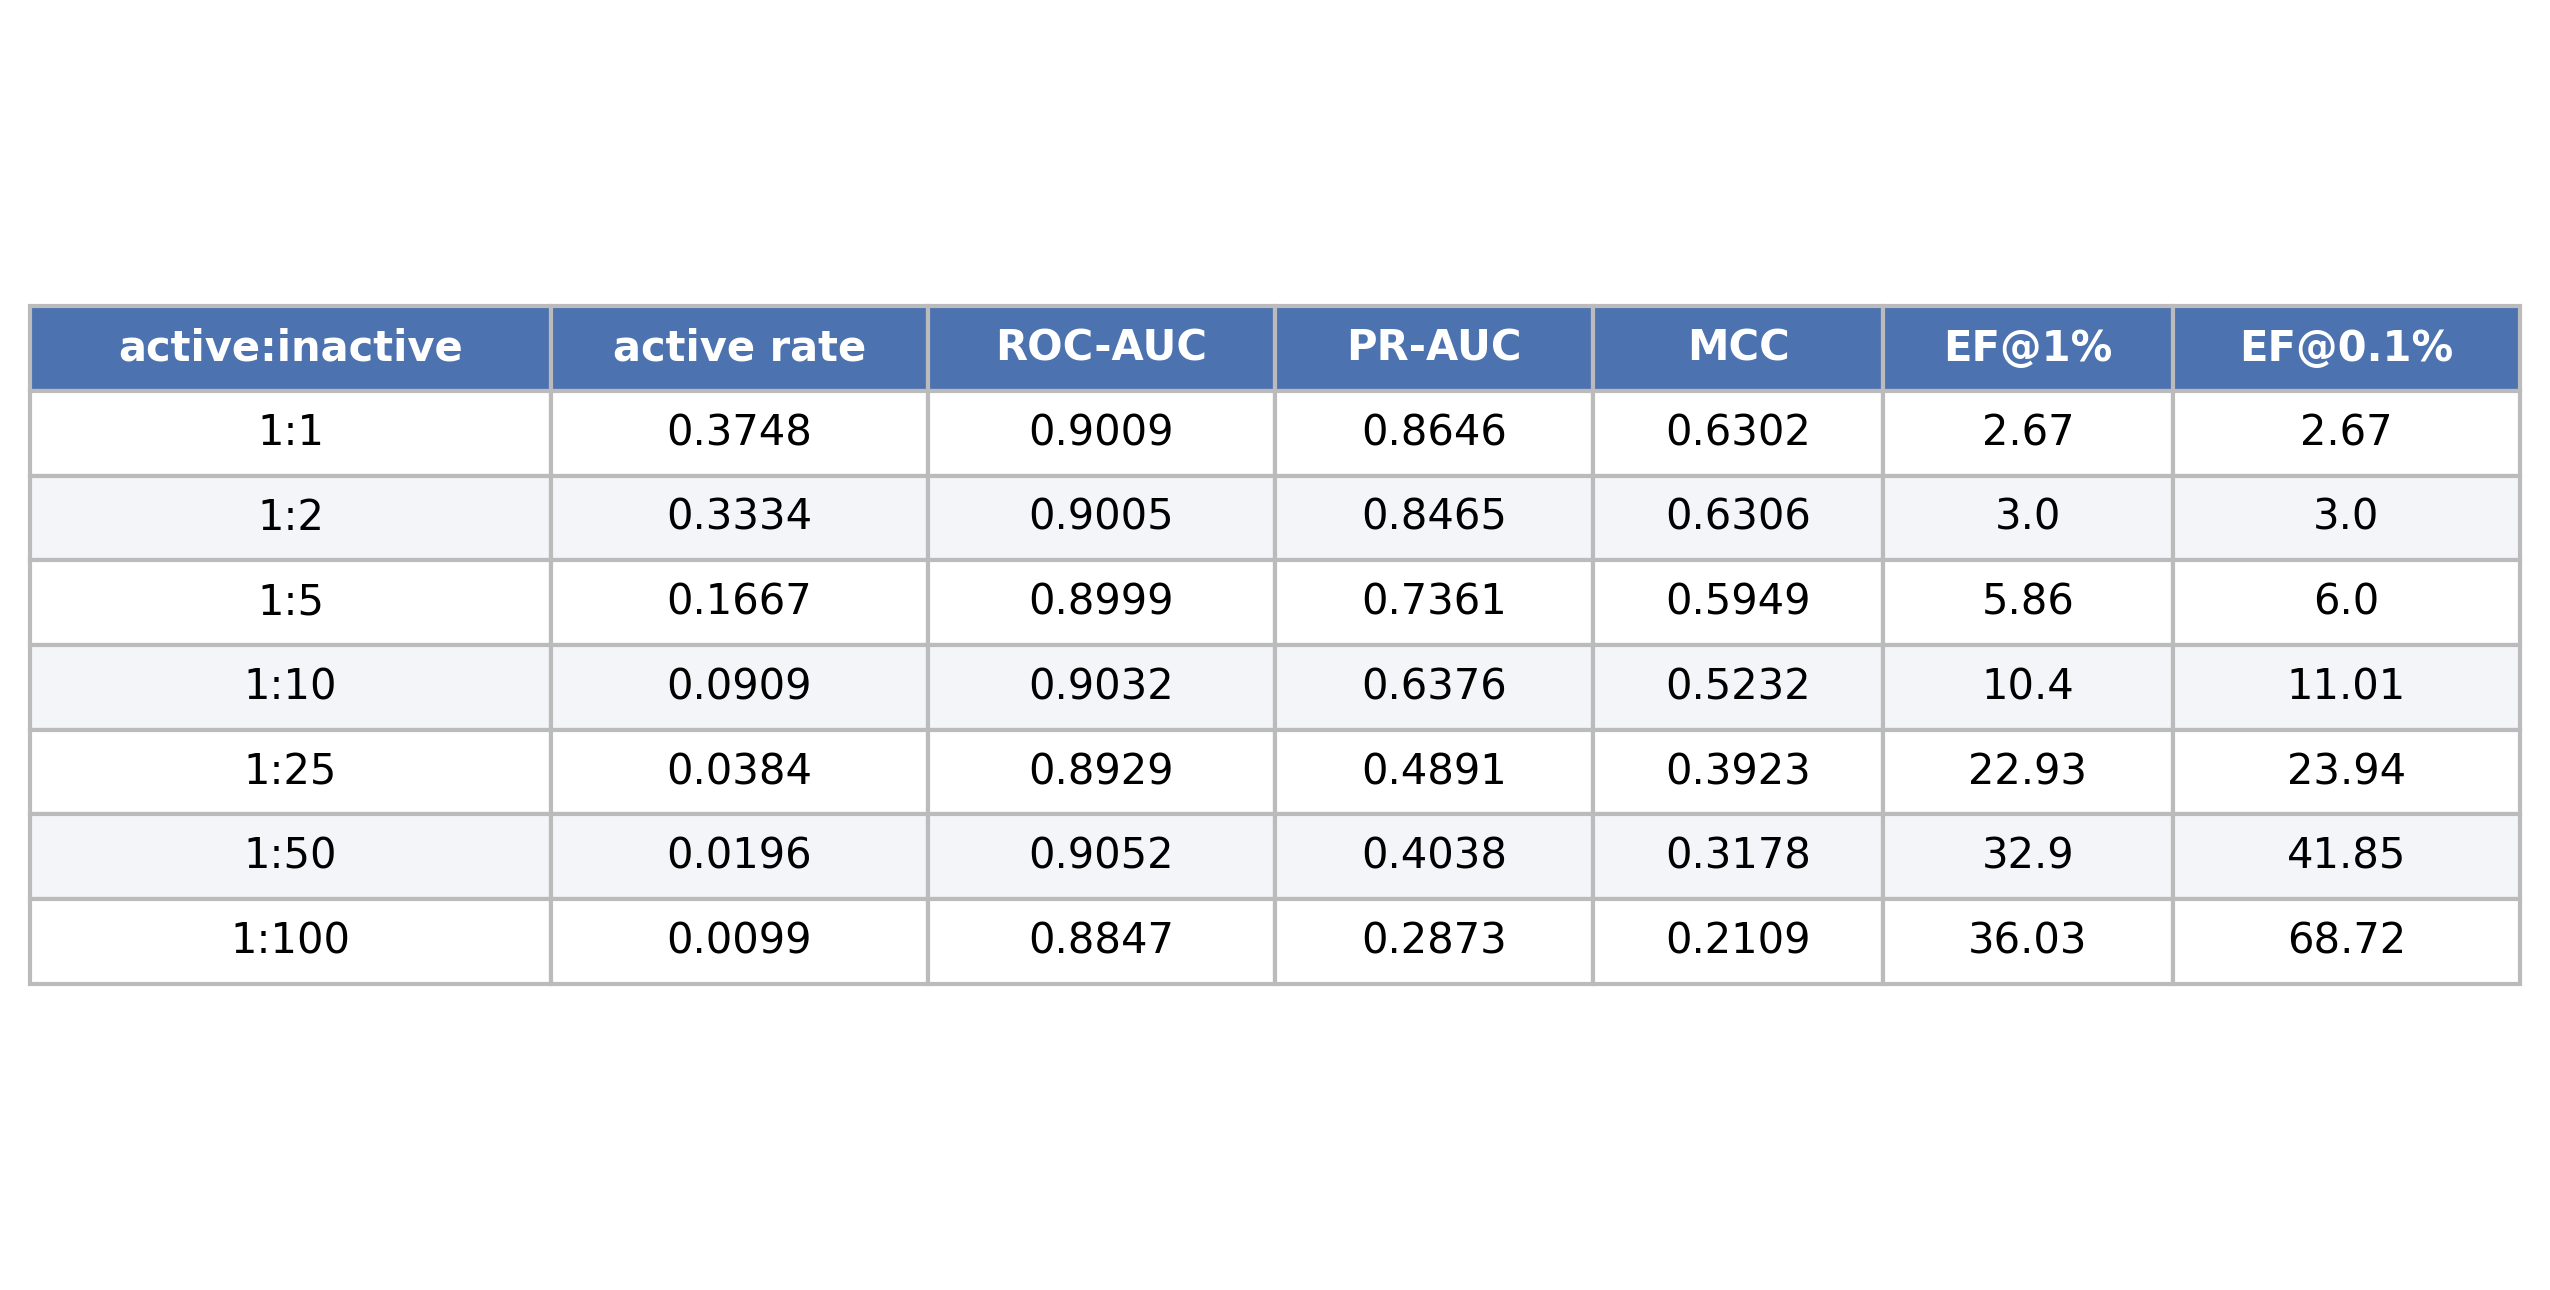

In [11]:
# Performance vs imbalance (Table C)
Image('03_Results/01_Figures/T03_performance_vs_imbalance.png')

**Assay/source-bias** — restricting the hold-out to each database separately leaves AUC essentially unchanged (ChEMBL 0.922, PubChem 0.900), so the model learns biology, not a source artefact.

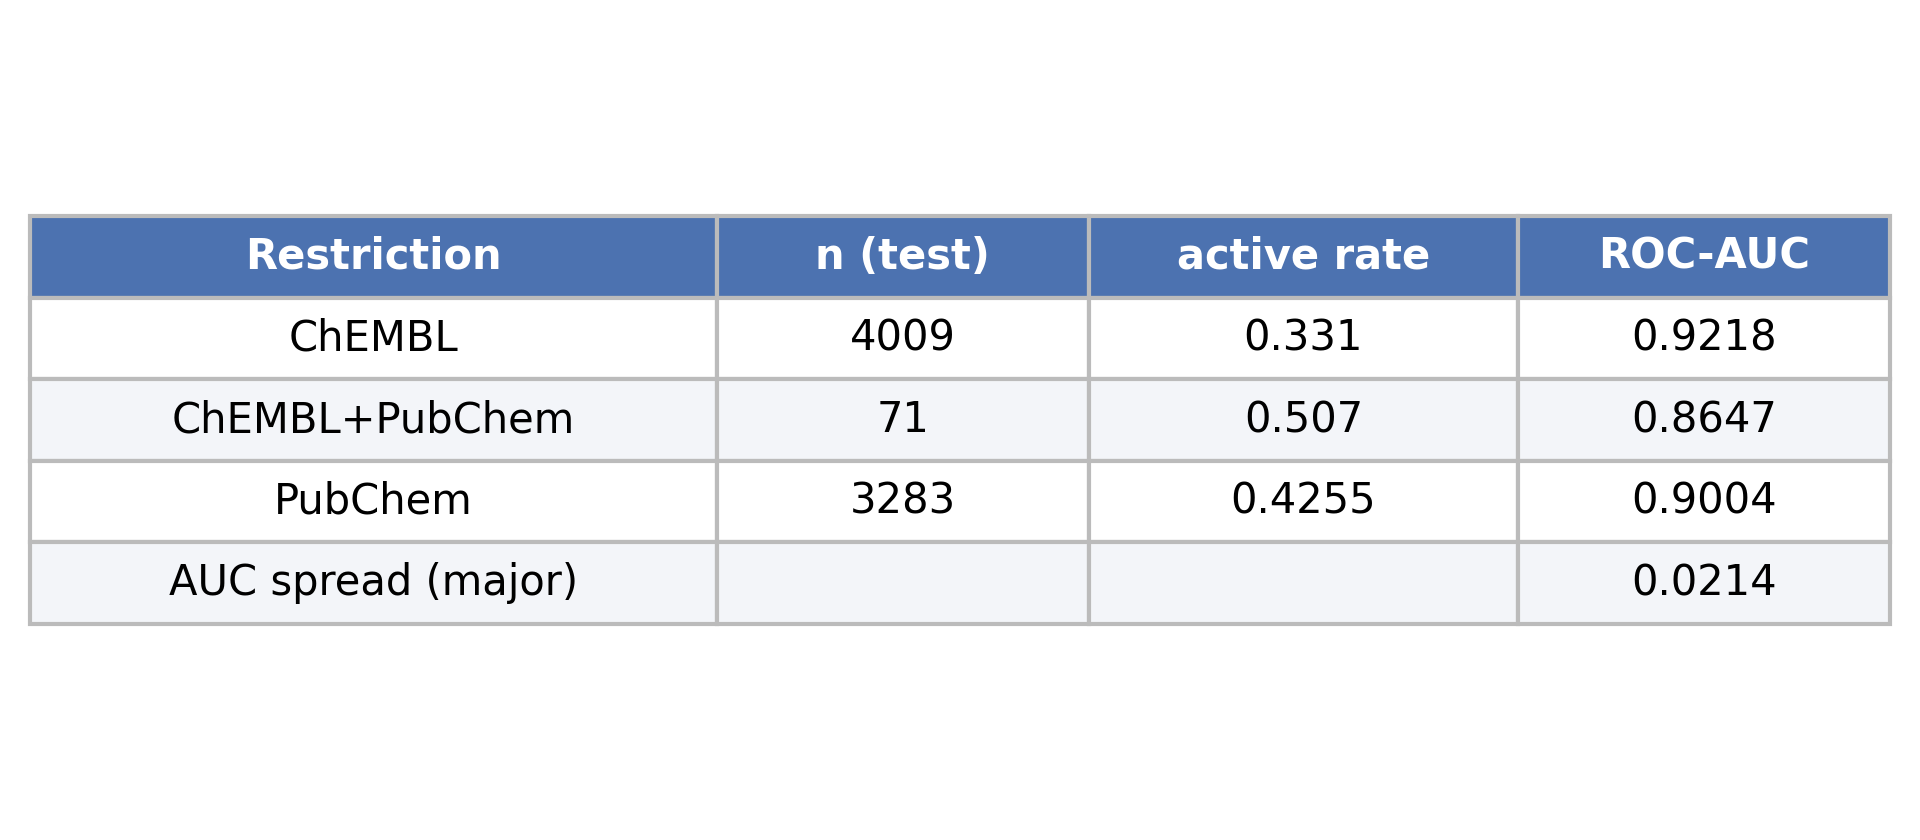

In [12]:
# Assay/source bias (Table E)
Image('03_Results/01_Figures/T05_assay_source_bias.png')

**External (provenance-disjoint) validation** — train on one database, test on the other. Transfer is above-chance but moderate (mean AUC 0.69 vs internal 0.90): a genuine cross-database domain shift, reported transparently as a limitation.

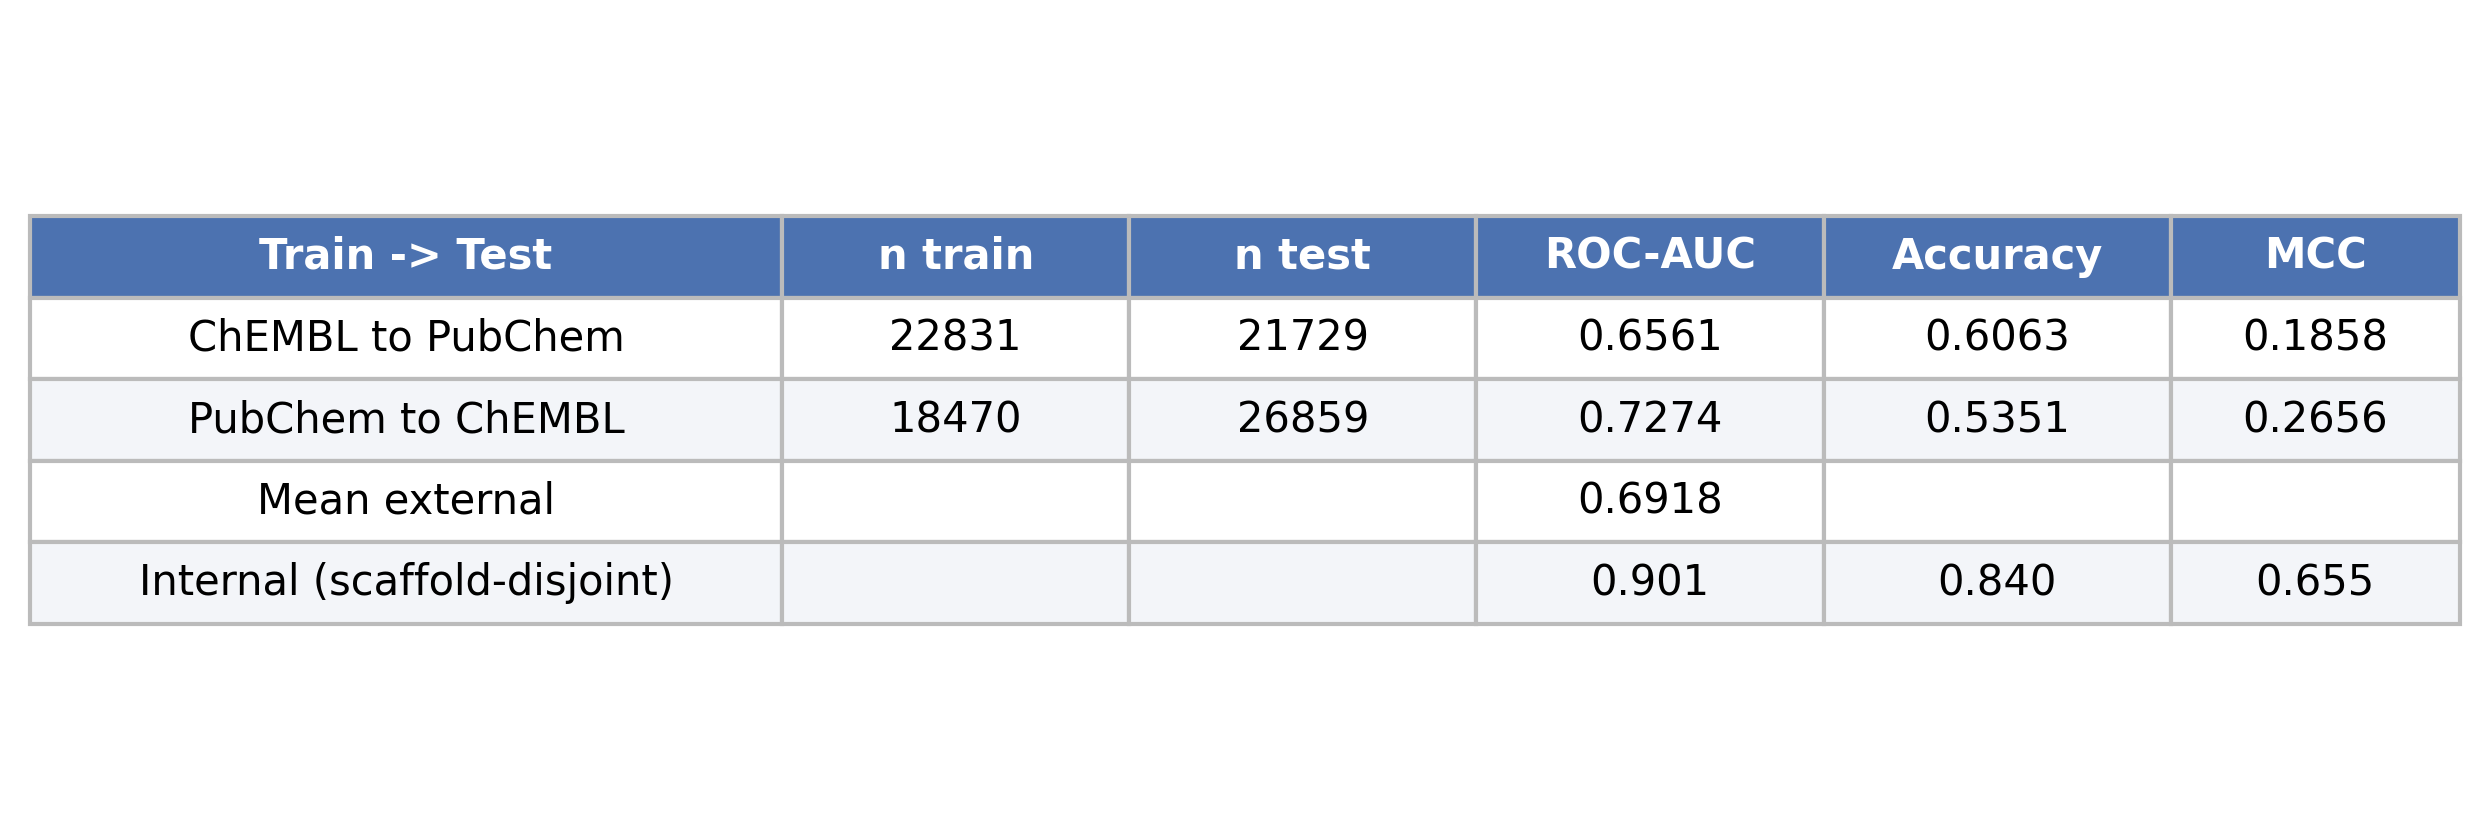

In [13]:
# External cross-source validation (Table D)
Image('03_Results/01_Figures/T04_external_cross_source.png')

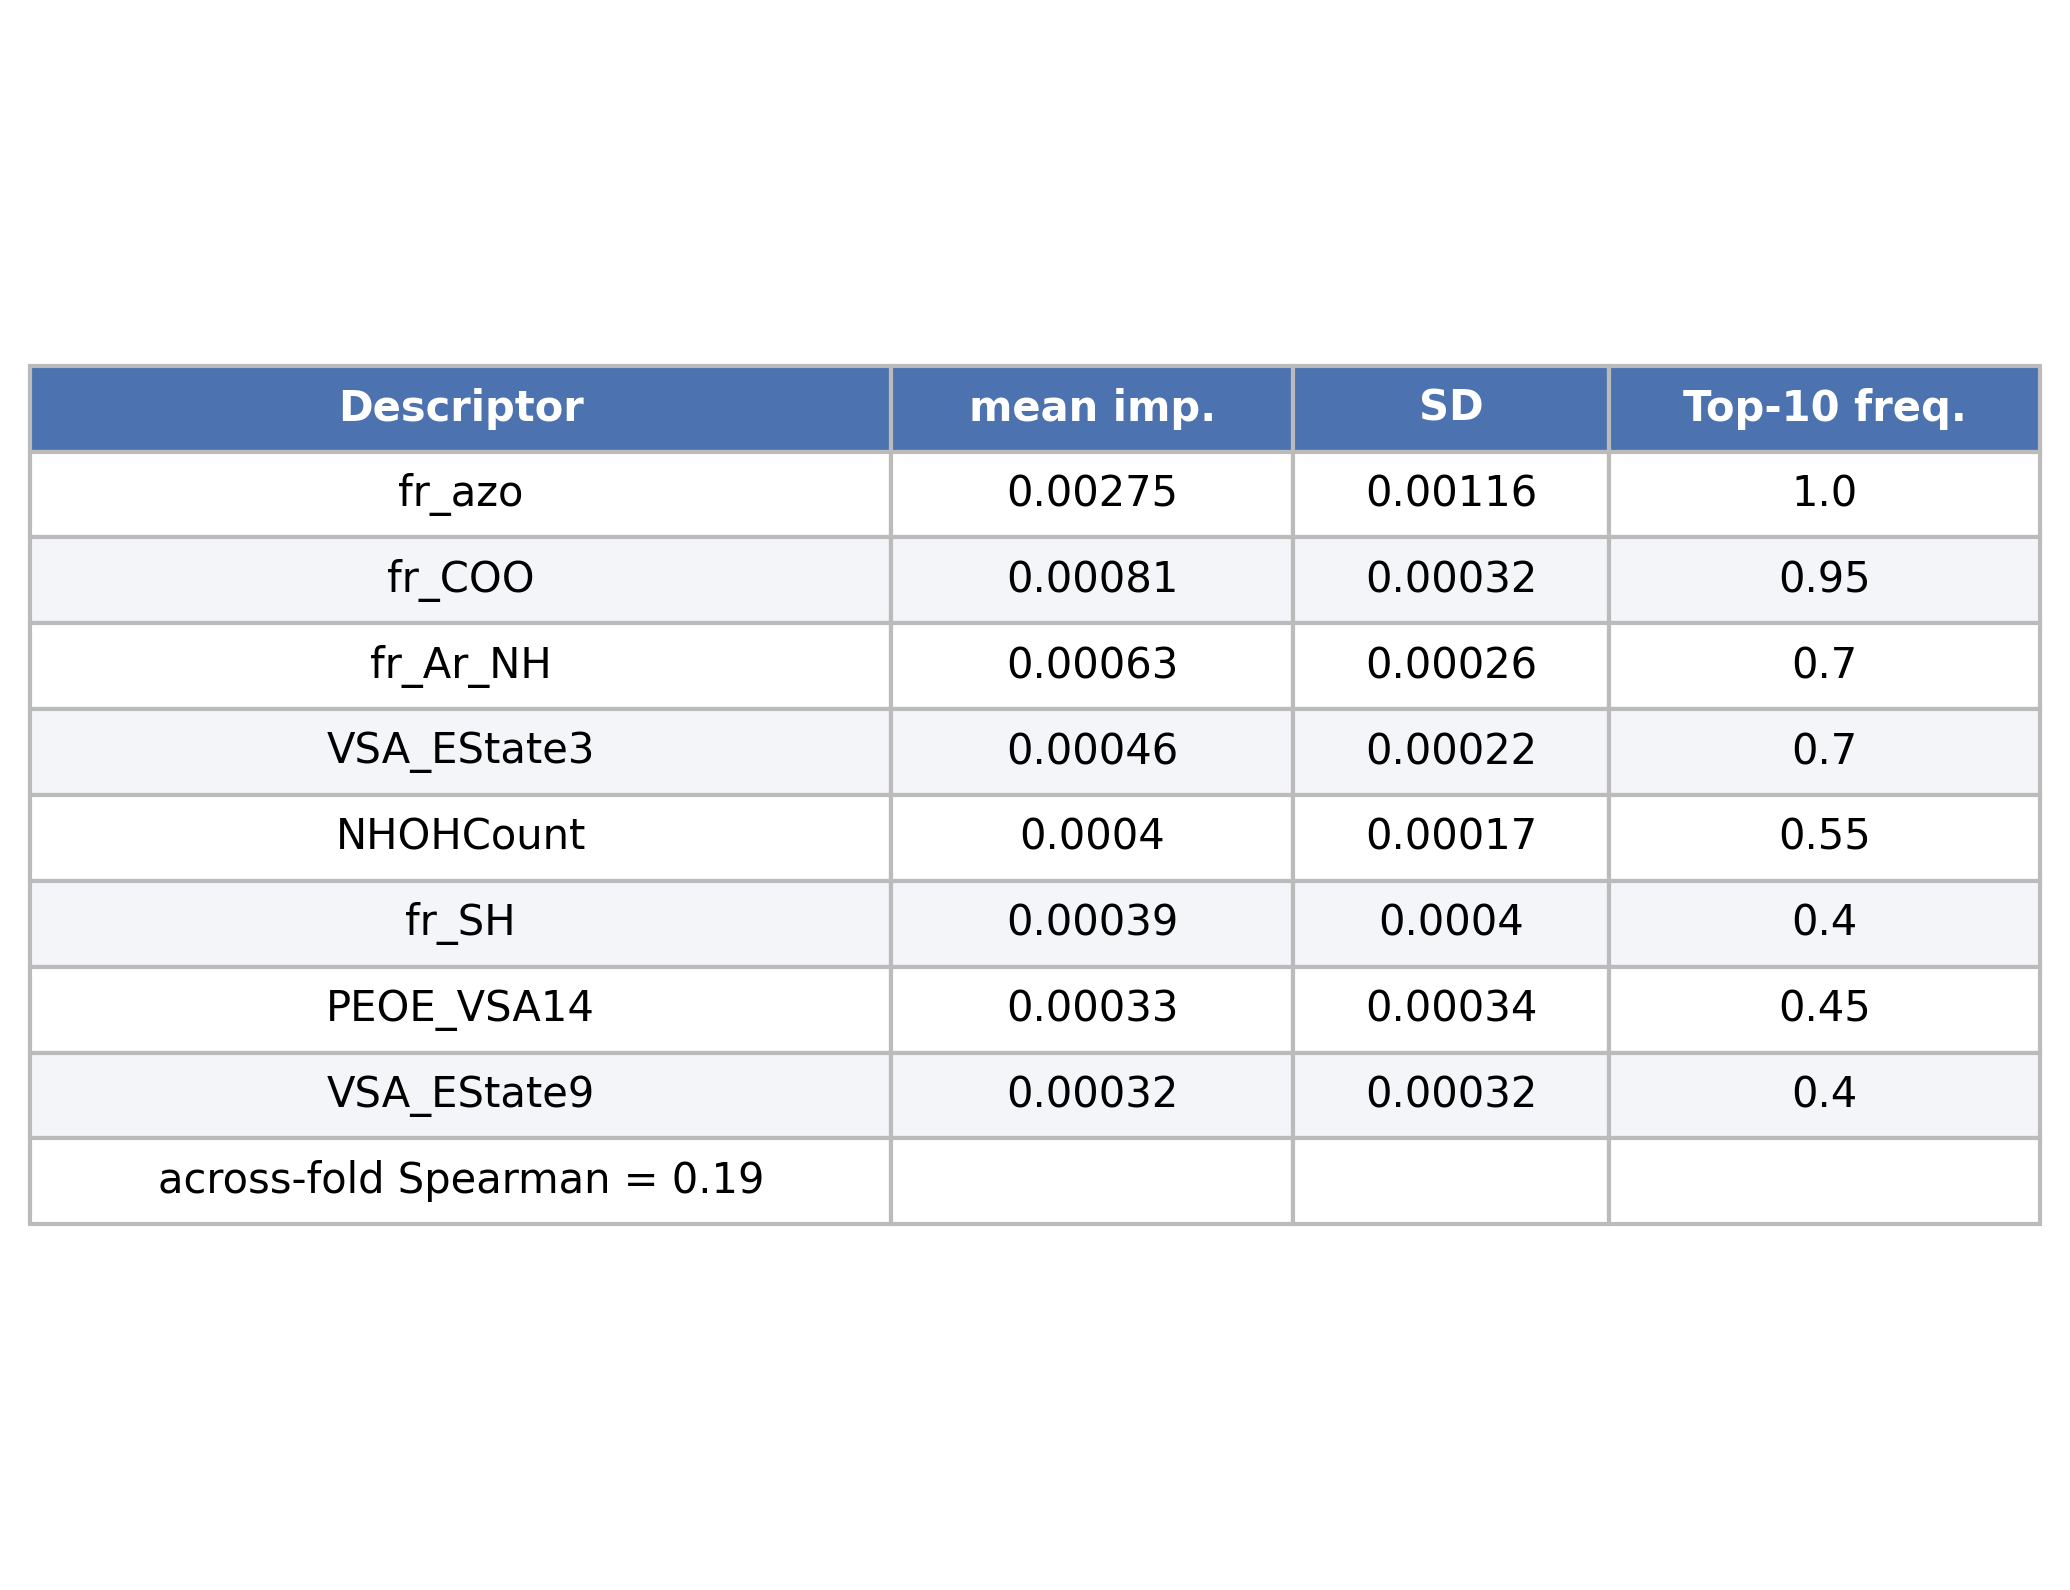

In [14]:
# Feature stability (Table F)
Image('03_Results/01_Figures/T06_feature_stability.png')

## 11. Honest limitations

- **Full-set accuracy (0.84)** is near the assay's own reproducibility limit; ~0.998 is not physically attainable without leakage.
- **Cross-database transfer is moderate** (external AUC 0.69) — a real domain shift; primary claims use the internal scaffold-disjoint result.
- **XAI stability**: the *top* features are reproducible, but the full 100-descriptor ranking is noisy (most descriptors are near-zero importance), so interpretability claims are restricted to the top features.

## 12. Reproduce everything with one command

```bash
git clone https://github.com/ShabanAhmad/DeepEntXAI.git
cd DeepEntXAI
pip install -r 01_Code/requirements.txt
python 00_run_all.py            # runs the whole pipeline, CPU, ~scaffold-disjoint
```

The pipeline is fully numbered (stages 01–15) and every figure/table is numbered (F01–F12, T01–T06). See `REVISION_RESPONSE.md` for the point-by-point reviewer replies.

---
*This notebook is a self-contained showcase; the embedded figures are the actual pipeline outputs. © the authors. Code under MIT.*